In [5]:
%matplotlib inline
%config InlineBackend.figure_format = 'retina'

In [6]:
import platform, matplotlib as mpl
from matplotlib.font_manager import FontProperties, findfont

def first_ok(cands):
    for name in cands:
        try:
            findfont(FontProperties(family=name), fallback_to_default=False)
            return name
        except Exception:
            pass
    return None

sys = platform.system()
if sys == "Darwin":   # macOS
    cjk_candidates = ["Songti SC", "Hiragino Sans GB", "STHeiti", "PingFang SC",   ]
elif sys == "Windows":
    cjk_candidates = ["Microsoft YaHei", "SimHei", "NSimSun", "KaiTi"]
else:                 # Linux
    cjk_candidates = ["Noto Sans CJK SC", "Source Han Sans SC", "WenQuanYi Micro Hei", "AR PL UMing CN"]

cjk = first_ok(cjk_candidates)

#（可选）清理字体缓存，改完配置后建议重启 kernel
# import shutil; shutil.rmtree(mpl.get_cachedir(), ignore_errors=True)

mpl.rcParams.update({
    # 关键顺序：STIX（英文/数学） → DejaVu Sans（含 U+2212） → 中文
    "font.family": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),
    "font.sans-serif": ["STIXGeneral", "DejaVu Sans"] + ([cjk] if cjk else []),

    # 数学字体固定用 STIX，防止落到“default”
    "mathtext.fontset": "stix",
    "mathtext.rm": "STIXGeneral",
    "mathtext.it": "STIXGeneral:italic",
    "mathtext.bf": "STIXGeneral:bold",

    "axes.unicode_minus": True,   # 使用 Unicode '−'（由 STIX/DejaVu 提供）
    "text.usetex": False,         # 没有配置 CJK 的 LaTeX 时必须关闭
    'font.size': 16, 
})
#print("CJK fallback:", cjk or "未找到；建议安装 Noto Sans CJK / 思源黑体 / 微软雅黑 / 苹方")

课堂练习：

利用梯形积分法和辛普森积分法计算

$$
\int_0^1 \frac{4}{1+x^2} dx
$$

对比解析解果 $\pi$ 的误差

1. 计算梯形积分
$$
\boxed{
\int_a^b f(x)\,dx \approx \frac{h}{2}\big(f(a)+f(b)\big).
}
$$

和利用复化梯形积分函数
```python
def trapezoid(f, a, b, n):
    """
    f: 函数
    a: 下区间
    b: 上区间
    n: 分区数
    """
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    return h * ( 0.5*f(x[0]) + np.sum(f(x[1:-1])) + 0.5*f(x[-1]) )
```

2. 计算辛普森法积分
$$
\boxed{
\int_a^b f(x)\,dx 
\approx
\frac{b-a}{6}\Big[f(a)+4f\!\left(\tfrac{a+b}{2}\right)+f(b)\Big].
}
$$

和利用复化辛普森积分函数

```python
def simpson(f, a, b, n):
    if n%2 == 1:
        n += 1

    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    
    return h/3 * ( f(x[0]) +  4 * np.sum(f(x[1:n:2])) + 2 * np.sum(f(x[2:n-1:2])) + f(x[-1]) )
```

梯形积分法结果:
n=  1: I_n = 3.000000000000, 误差 = 1.415926535898e-01, 相对误差 = 4.507034144863e-02
n=  2: I_n = 3.100000000000, 误差 = 4.159265358979e-02, 相对误差 = 1.323935283025e-02
n=  4: I_n = 3.131176470588, 误差 = 1.041618300156e-02, 相对误差 = 3.315574025695e-03
n=  8: I_n = 3.138988494491, 误差 = 2.604159098704e-03, 相对误差 = 8.289295863130e-04
n= 16: I_n = 3.140941612041, 误差 = 6.510415484042e-04, 相对误差 = 2.072329611735e-04
n= 32: I_n = 3.141429893175, 误差 = 1.627604148187e-04, 相对误差 = 5.180824911616e-05

辛普森积分法结果:
n=  1: I_n = 3.133333333333, 误差 = 8.259320256460e-03, 相对误差 = 2.629023290789e-03
n=  2: I_n = 3.133333333333, 误差 = 8.259320256460e-03, 相对误差 = 2.629023290789e-03
n=  4: I_n = 3.141568627451, 误差 = 2.402613881314e-05, 相对误差 = 7.647757511046e-06
n=  8: I_n = 3.141592502459, 误差 = 1.511310863123e-07, 相对误差 = 4.810651888289e-08
n= 16: I_n = 3.141592651225, 误差 = 2.364971329882e-09, 相对误差 = 7.527937548428e-10
n= 32: I_n = 3.141592653553, 误差 = 3.695665995451e-11, 相对误差 = 1.176367022385e-11


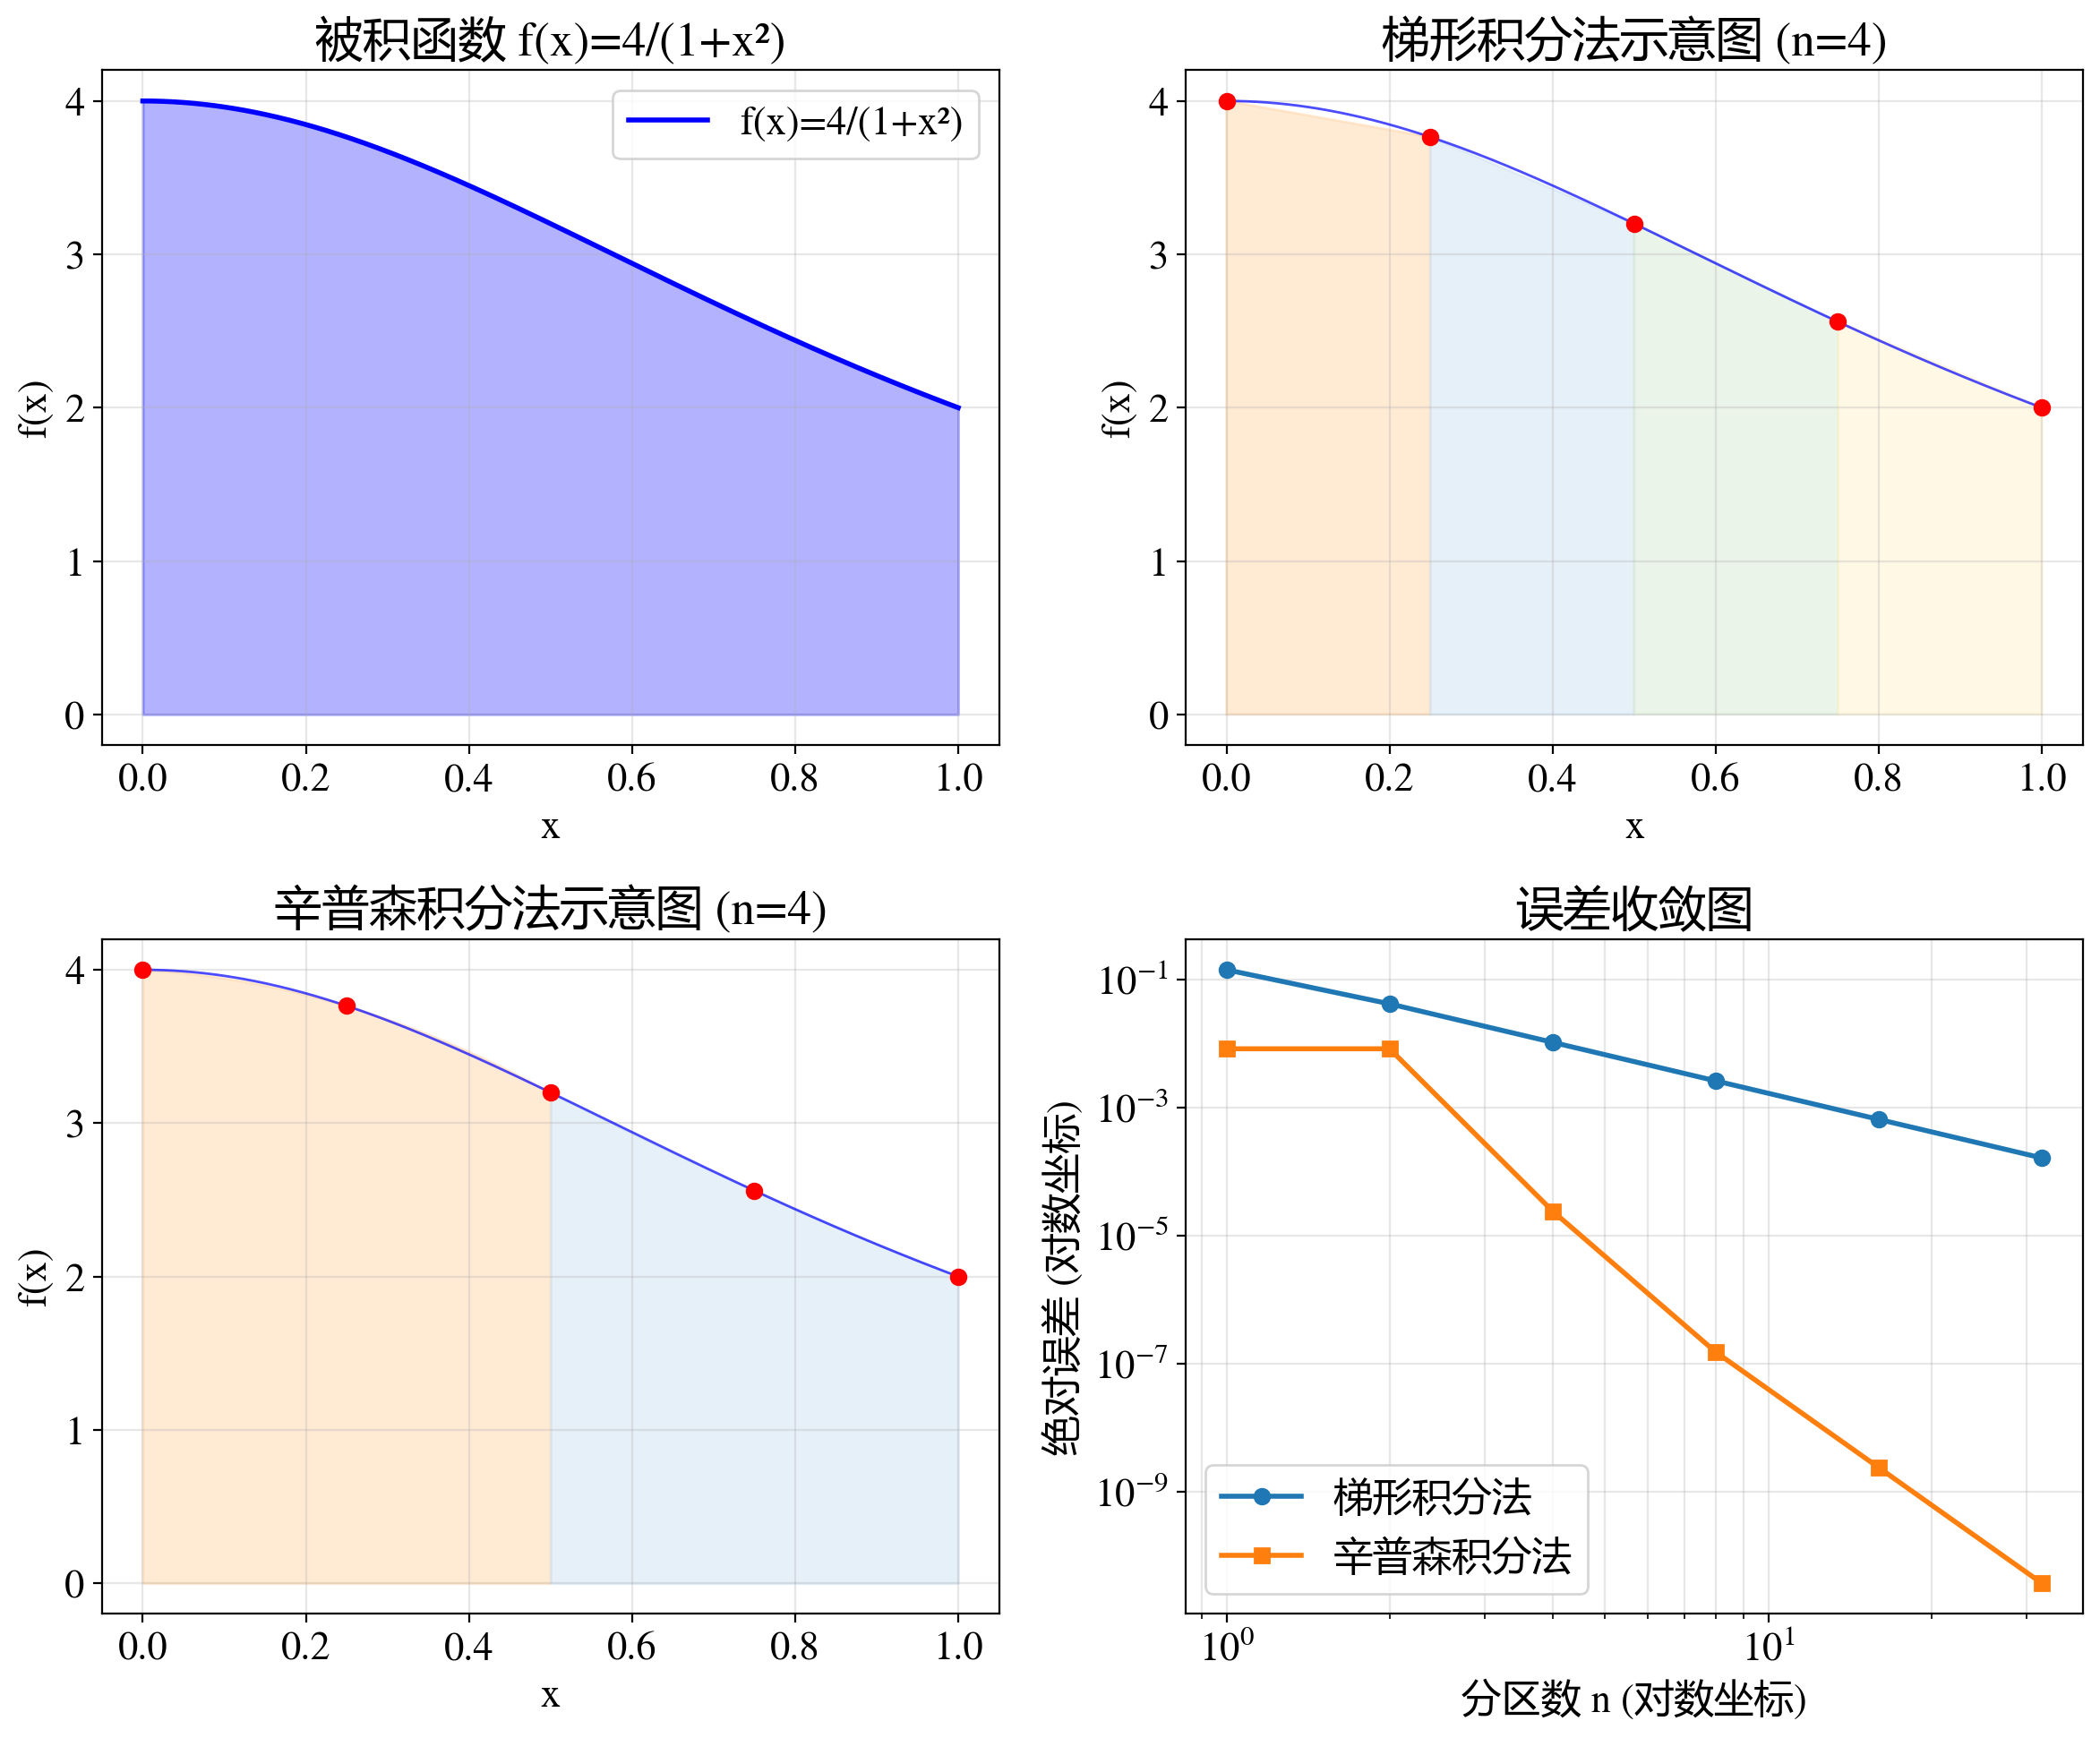


误差分析总结:
解析解 I_true = π ≈ 3.141592653589793

收敛阶估计:
n=1到n=2:
  梯形积分法: 误差比 = 3.40 (理论O(1/n²): 约4.00)
  辛普森积分法: 误差比 = 1.00 (理论O(1/n⁴): 约16.00)

n=2到n=4:
  梯形积分法: 误差比 = 3.99 (理论O(1/n²): 约4.00)
  辛普森积分法: 误差比 = 343.76 (理论O(1/n⁴): 约16.00)

n=4到n=8:
  梯形积分法: 误差比 = 4.00 (理论O(1/n²): 约4.00)
  辛普森积分法: 误差比 = 158.98 (理论O(1/n⁴): 约16.00)

n=8到n=16:
  梯形积分法: 误差比 = 4.00 (理论O(1/n²): 约4.00)
  辛普森积分法: 误差比 = 63.90 (理论O(1/n⁴): 约16.00)

n=16到n=32:
  梯形积分法: 误差比 = 4.00 (理论O(1/n²): 约4.00)
  辛普森积分法: 误差比 = 63.99 (理论O(1/n⁴): 约16.00)



In [22]:
import numpy as np
import matplotlib.pyplot as plt

# 定义被积函数
def f(x):
    return 4 / (1 + x**2)

# 梯形积分法
def trapezoid(f, a, b, n):
    """
    f: 函数
    a: 下区间
    b: 上区间
    n: 分区数
    """
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    return h * (0.5*f(x[0]) + np.sum(f(x[1:-1])) + 0.5*f(x[-1]))

# 辛普森积分法
def simpson(f, a, b, n):
    if n % 2 == 1:
        n += 1
    
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    return h/3 * (f(x[0]) + 4 * np.sum(f(x[1:n:2])) + 2 * np.sum(f(x[2:n-1:2])) + f(x[-1]))

# 解析解
I_true = np.pi

# 测试不同的n值
n_values = [1, 2, 4, 8, 16, 32]

print("梯形积分法结果:")
print("="*60)
for n in n_values:
    approx = trapezoid(f, 0, 1, n)
    error = abs(approx - I_true)
    print(f"n={n:3d}: I_n = {approx:.12f}, 误差 = {error:.12e}, 相对误差 = {error/I_true:.12e}")

print("\n辛普森积分法结果:")
print("="*60)
for n in n_values:
    approx = simpson(f, 0, 1, n)
    error = abs(approx - I_true)
    print(f"n={n:3d}: I_n = {approx:.12f}, 误差 = {error:.12e}, 相对误差 = {error/I_true:.12e}")

# 可视化结果
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 绘制函数图形
x_fine = np.linspace(0, 1, 400)
y_fine = f(x_fine)
axes[0, 0].plot(x_fine, y_fine, 'b-', linewidth=2, label='f(x)=4/(1+x²)')
axes[0, 0].fill_between(x_fine, y_fine, alpha=0.3, color='blue')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')
axes[0, 0].set_title('被积函数 f(x)=4/(1+x²)')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 绘制梯形积分法示意图
n_trap = 4
x_nodes_trap = np.linspace(0, 1, n_trap+1)
y_nodes_trap = f(x_nodes_trap)
axes[0, 1].plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.7, label='f(x)')

# 绘制梯形
colors_trap = ['#ffd6aa', '#cfe2f3', '#d9ead3', '#fff2cc']
for i in range(len(x_nodes_trap)-1):
    xs = [x_nodes_trap[i], x_nodes_trap[i], x_nodes_trap[i+1], x_nodes_trap[i+1]]
    ys = [0, y_nodes_trap[i], y_nodes_trap[i+1], 0]
    axes[0, 1].fill(xs, ys, alpha=0.5, color=colors_trap[i % len(colors_trap)])

axes[0, 1].scatter(x_nodes_trap, y_nodes_trap, color='red', zorder=5)
axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('f(x)')
axes[0, 1].set_title(f'梯形积分法示意图 (n={n_trap})')
axes[0, 1].grid(True, alpha=0.3)

# 3. 绘制辛普森积分法示意图
n_simp = 4  # 需要偶数个子区间
x_nodes_simp = np.linspace(0, 1, n_simp+1)
y_nodes_simp = f(x_nodes_simp)
axes[1, 0].plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.7, label='f(x)')

# 绘制抛物线
colors_simp = ['#ffd6aa', '#cfe2f3']
for i in range(0, len(x_nodes_simp)-2, 2):
    xs = x_nodes_simp[i:i+3]
    ys = y_nodes_simp[i:i+3]
    xx = np.linspace(xs[0], xs[2], 100)
    coeff = np.polyfit(xs, ys, 2)
    yy = np.polyval(coeff, xx)
    axes[1, 0].fill_between(xx, yy, alpha=0.5, color=colors_simp[i//2 % len(colors_simp)])

axes[1, 0].scatter(x_nodes_simp, y_nodes_simp, color='red', zorder=5)
axes[1, 0].set_xlabel('x')
axes[1, 0].set_ylabel('f(x)')
axes[1, 0].set_title(f'辛普森积分法示意图 (n={n_simp})')
axes[1, 0].grid(True, alpha=0.3)

# 4. 绘制误差收敛图
trap_errors = []
simp_errors = []

for n in n_values:
    trap_approx = trapezoid(f, 0, 1, n)
    simp_approx = simpson(f, 0, 1, n)
    trap_errors.append(abs(trap_approx - I_true))
    simp_errors.append(abs(simp_approx - I_true))

axes[1, 1].loglog(n_values, trap_errors, 'o-', label='梯形积分法', linewidth=2)
axes[1, 1].loglog(n_values, simp_errors, 's-', label='辛普森积分法', linewidth=2)
axes[1, 1].set_xlabel('分区数 n (对数坐标)')
axes[1, 1].set_ylabel('绝对误差 (对数坐标)')
axes[1, 1].set_title('误差收敛图')
axes[1, 1].grid(True, alpha=0.3, which='both')
axes[1, 1].legend()

plt.tight_layout()
plt.show()

# 打印误差分析
print("\n" + "="*60)
print("误差分析总结:")
print("="*60)
print("解析解 I_true = π ≈", np.pi)
print()

# 计算收敛阶
print("收敛阶估计:")
for i in range(len(n_values)-1):
    n1, n2 = n_values[i], n_values[i+1]
    trap1, trap2 = trapezoid(f, 0, 1, n1), trapezoid(f, 0, 1, n2)
    simp1, simp2 = simpson(f, 0, 1, n1), simpson(f, 0, 1, n2)
    
    trap_error_ratio = abs(trap1 - I_true) / abs(trap2 - I_true)
    simp_error_ratio = abs(simp1 - I_true) / abs(simp2 - I_true)
    
    print(f"n={n1}到n={n2}:")
    print(f"  梯形积分法: 误差比 = {trap_error_ratio:.2f} (理论O(1/n²): 约{(n2/n1)**2:.2f})")
    print(f"  辛普森积分法: 误差比 = {simp_error_ratio:.2f} (理论O(1/n⁴): 约{(n2/n1)**4:.2f})")
    print()

课堂练习：
利用龙贝格算法调用梯形积分计算积分，要求误差小于$10^{-8}$

$$
S = \int_0^1 \frac{\ln (1+x)}{1 + x^2} d x
$$

In [27]:
import numpy as np

# 定义被积函数：f(x) = ln(1+x)/(1+x²)
def f(x):
    return np.log(1 + x) / (1 + x**2)

# 梯形积分函数
def trapezoid(func, a, b, n):
    """
    梯形积分法
    func: 被积函数
    a: 积分下限
    b: 积分上限
    n: 区间分割数
    """
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = func(x)
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

# 龙贝格算法函数
def romberg(func, a, b, error, n0=2):
    """
    龙贝格积分算法
    func: 被积函数
    a: 积分下限
    b: 积分上限
    error: 目标误差
    n0: 初始区间分割数
    """
    T0 = trapezoid(func, a, b, n0)
    
    for k in range(1, 100):
        # 加倍区间数
        T1 = trapezoid(func, a, b, n0 * 2**k)
        
        # 检查误差
        if abs(T1 - T0) / 3.0 < error:
            # 使用外推公式提高精度
            result = T1 * 4/3.0 - T0 / 3.0
            return result, k
        else:
            T0 = T1
    
    # 如果循环结束仍未达到精度要求
    print("警告: 未在100次迭代内达到目标精度")
    return T1 * 4/3.0 - T0 / 3.0, 100

# 测试龙贝格算法
a, b = 0, 1
target_error = 1e-8

print("计算积分: ∫₀¹ ln(1+x)/(1+x²) dx")
print("="*60)

# 使用龙贝格算法
result, iterations = romberg(f, a, b, target_error)

print(f"龙贝格算法结果: {result:.15f}")
print(f"所需迭代次数: {iterations}")
print(f"目标误差: {target_error}")
print()

# 比较不同误差要求下的结果
print("不同误差要求下的龙贝格算法结果:")
print("-"*60)

error_levels = [1e-4, 1e-6, 1e-8, 1e-10]

for err in error_levels:
    res, iters = romberg(f, a, b, err)
    print(f"目标误差: {err:10.1e} -> 结果: {res:.12f}, 迭代次数: {iters}")

计算积分: ∫₀¹ ln(1+x)/(1+x²) dx
龙贝格算法结果: 0.272198261287950
所需迭代次数: 11
目标误差: 1e-08

不同误差要求下的龙贝格算法结果:
------------------------------------------------------------
目标误差:    1.0e-04 -> 结果: 0.272198289164, 迭代次数: 4
目标误差:    1.0e-06 -> 结果: 0.272198261288, 迭代次数: 8
目标误差:    1.0e-08 -> 结果: 0.272198261288, 迭代次数: 11
目标误差:    1.0e-10 -> 结果: 0.272198261288, 迭代次数: 14


In [29]:
import numpy as np

# 测试函数1：∫₀¹ 4/(1+x²) dx = π
def f_test1(x):
    return 4 / (1 + x**2)

# 测试函数2：∫₀¹ ln(1+x)/(1+x²) dx
def f_test2(x):
    return np.log(1 + x) / (1 + x**2)

# 改进的龙贝格算法，使用完整的龙贝格表
def romberg_full(func, a, b, error=1e-8, max_iter=20):
    """
    完整的龙贝格算法，构建龙贝格表
    """
    # 初始化龙贝格表
    R = np.zeros((max_iter, max_iter))
    
    # 计算第一个梯形积分 (n=1)
    R[0, 0] = trapezoid(func, a, b, 1)
    
    for i in range(1, max_iter):
        # 加倍区间数，计算梯形积分
        n = 2**i
        R[i, 0] = trapezoid(func, a, b, n)
        
        # 外推计算更高阶的近似
        for j in range(1, i+1):
            R[i, j] = (4**j * R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        
        # 检查收敛
        if i > 0 and abs(R[i, i] - R[i-1, i-1]) < error:
            return R[i, i], i, R[:i+1, :i+1]
    
    # 返回最后一次迭代的结果
    return R[max_iter-1, max_iter-1], max_iter-1, R

print("测试1: ∫₀¹ 4/(1+x²) dx = π")
print("="*60)

result1, iter1, table1 = romberg_full(f_test1, 0, 1, error=1e-10)
print(f"龙贝格算法结果: {result1:.15f}")
print(f"精确值 π:       {np.pi:.15f}")
print(f"绝对误差:       {abs(result1 - np.pi):.15e}")
print(f"迭代次数:       {iter1}")
print()

print("龙贝格表 (前5行):")
print("-"*60)
for i in range(min(5, len(table1))):
    row_str = ""
    for j in range(i+1):
        row_str += f"R[{i},{j}] = {table1[i,j]:.12f}  "
    print(row_str)
print()

print("测试2: ∫₀¹ ln(1+x)/(1+x²) dx")
print("="*60)

# 已知这个积分的精确值（Catalan常数相关）
# ∫₀¹ ln(1+x)/(1+x²) dx = (π ln2)/8
exact_value = np.pi * np.log(2) / 8
print(f"精确值 (π ln2)/8: {exact_value:.15f}")

result2, iter2, table2 = romberg_full(f_test2, 0, 1, error=1e-10)
print(f"龙贝格算法结果: {result2:.15f}")
print(f"绝对误差:       {abs(result2 - exact_value):.15e}")
print(f"迭代次数:       {iter2}")

测试1: ∫₀¹ 4/(1+x²) dx = π
龙贝格算法结果: 3.141592653589722
精确值 π:       3.141592653589793
绝对误差:       7.105427357601002e-14
迭代次数:       6

龙贝格表 (前5行):
------------------------------------------------------------
R[0,0] = 3.000000000000  
R[1,0] = 3.100000000000  R[1,1] = 3.133333333333  
R[2,0] = 3.131176470588  R[2,1] = 3.141568627451  R[2,2] = 3.142117647059  
R[3,0] = 3.138988494491  R[3,1] = 3.141592502459  R[3,2] = 3.141594094126  R[3,3] = 3.141585783762  
R[4,0] = 3.140941612041  R[4,1] = 3.141592651225  R[4,2] = 3.141592661143  R[4,3] = 3.141592638397  R[4,4] = 3.141592665278  

测试2: ∫₀¹ ln(1+x)/(1+x²) dx
精确值 (π ln2)/8: 0.272198261287950
龙贝格算法结果: 0.272198261287951
绝对误差:       8.881784197001252e-16
迭代次数:       6


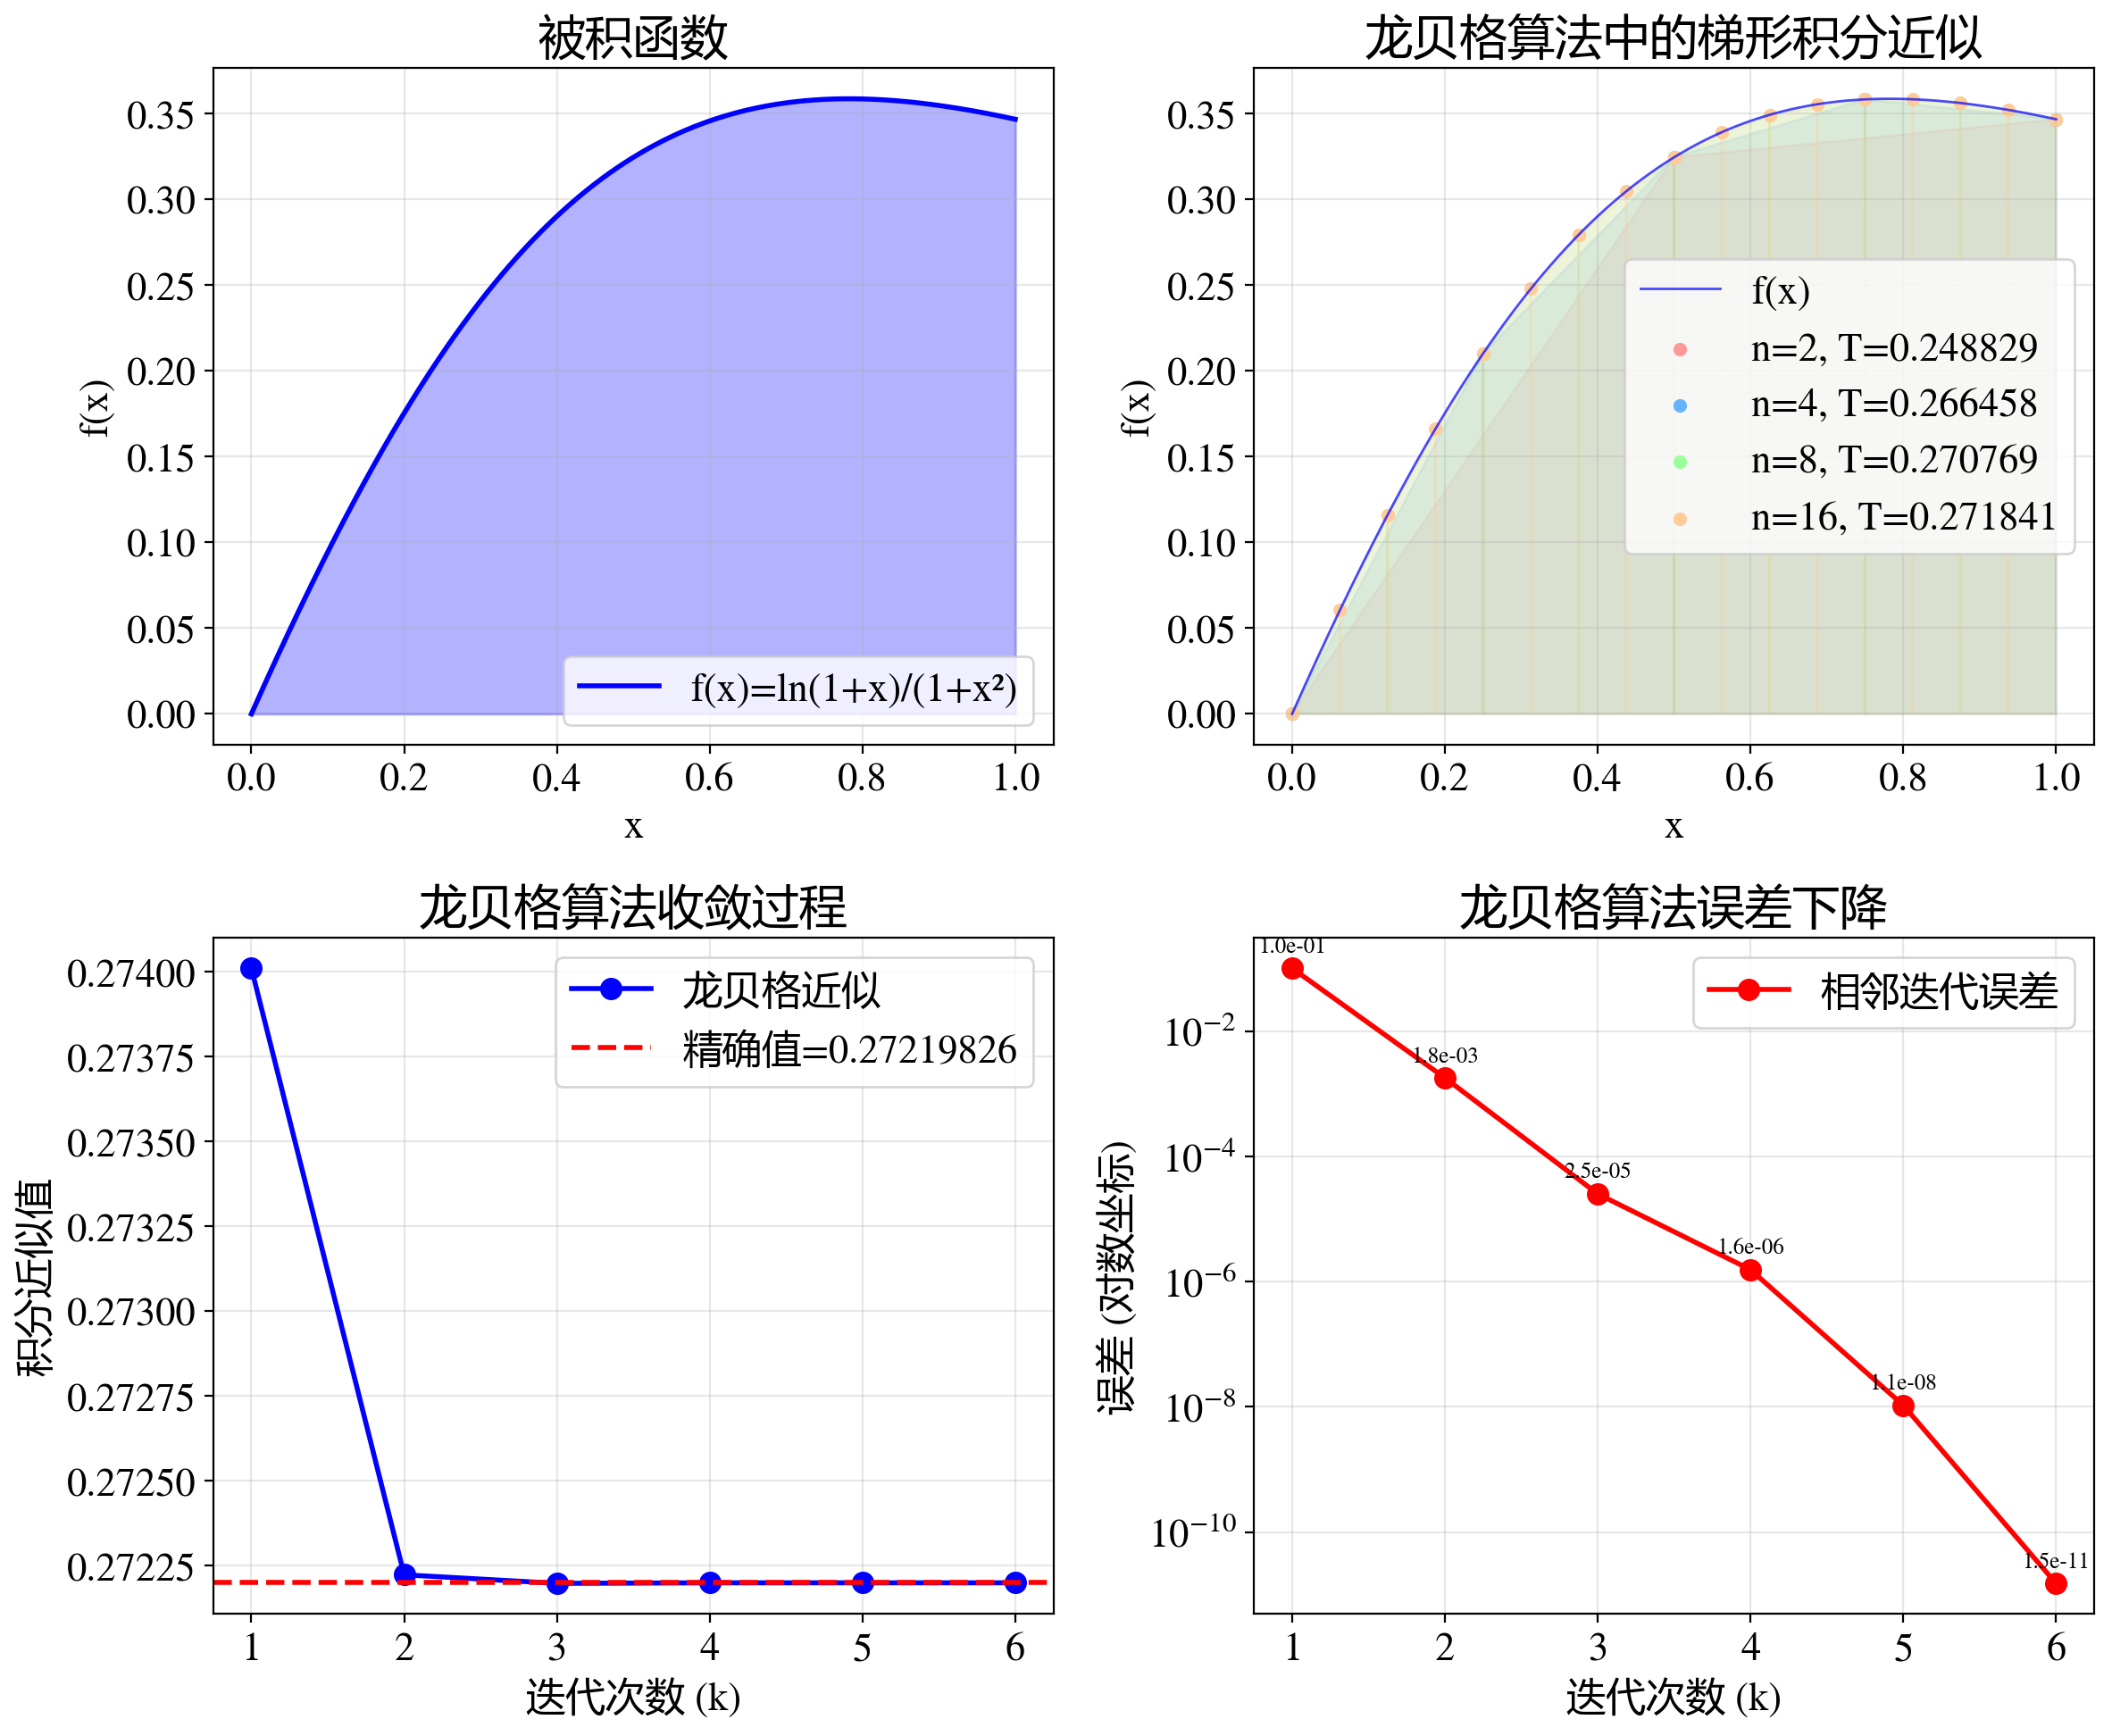

龙贝格表 (R[i,j]):
i   j=0         j=1         j=2         j=3         j=4         j=5
----------------------------------------------------------------------
0  0.17328680  
1  0.24882944  0.27401032  
2  0.26645761  0.27233367  0.27222189  
3  0.27076864  0.27220565  0.27219711  0.27219672  
4  0.27184119  0.27219871  0.27219825  0.27219827  0.27219827  
5  0.27210901  0.27219829  0.27219826  0.27219826  0.27219826  0.27219826  
6  0.27217595  0.27219826  0.27219826  0.27219826  0.27219826  0.27219826  
精确值: 0.2721982613


In [31]:
import numpy as np
import matplotlib.pyplot as plt

# 定义被积函数
def f(x):
    return np.log(1 + x) / (1 + x**2)

# 创建图形
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

# 1. 绘制函数图形
x_fine = np.linspace(0, 1, 400)
y_fine = f(x_fine)

axes[0, 0].plot(x_fine, y_fine, 'b-', linewidth=2, label='f(x)=ln(1+x)/(1+x²)')
axes[0, 0].fill_between(x_fine, y_fine, alpha=0.3, color='blue')
axes[0, 0].set_xlabel('x')
axes[0, 0].set_ylabel('f(x)')
axes[0, 0].set_title('被积函数')
axes[0, 0].grid(True, alpha=0.3)
axes[0, 0].legend()

# 2. 绘制龙贝格算法中的梯形积分近似
levels = [2, 4, 8, 16]  # 不同细分级别
colors = ['#ff9999', '#66b3ff', '#99ff99', '#ffcc99']

axes[0, 1].plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.7, label='f(x)')

for i, n in enumerate(levels):
    x_nodes = np.linspace(0, 1, n+1)
    y_nodes = f(x_nodes)
    
    # 绘制梯形
    for j in range(n):
        xs = [x_nodes[j], x_nodes[j], x_nodes[j+1], x_nodes[j+1]]
        ys = [0, y_nodes[j], y_nodes[j+1], 0]
        axes[0, 1].fill(xs, ys, alpha=0.2, color=colors[i])
    
    # 绘制节点
    axes[0, 1].scatter(x_nodes, y_nodes, color=colors[i], s=20, 
                      label=f'n={n}, T={trapezoid(f,0,1,n):.6f}')

axes[0, 1].set_xlabel('x')
axes[0, 1].set_ylabel('f(x)')
axes[0, 1].set_title('龙贝格算法中的梯形积分近似')
axes[0, 1].grid(True, alpha=0.3)
axes[0, 1].legend()

# 3. 绘制龙贝格算法的收敛过程
def romberg_convergence(func, a, b, max_iter=8):
    """计算龙贝格算法的收敛过程"""
    R = np.zeros((max_iter, max_iter))
    errors = []
    
    # 计算第一个梯形积分
    R[0, 0] = trapezoid(func, a, b, 1)
    
    for i in range(1, max_iter):
        # 加倍区间数
        n = 2**i
        R[i, 0] = trapezoid(func, a, b, n)
        
        # 外推
        for j in range(1, i+1):
            R[i, j] = (4**j * R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        
        # 记录对角线元素的误差
        errors.append(abs(R[i, i] - R[i-1, i-1]))
    
    return R, errors

# 已知精确值
exact_value = np.pi * np.log(2) / 8

R_table, errors = romberg_convergence(f, 0, 1, max_iter=7)

# 绘制龙贝格表的对角线元素
iterations = list(range(1, len(R_table)))
diag_values = [R_table[i, i] for i in iterations]

axes[1, 0].plot(iterations, diag_values, 'bo-', linewidth=2, markersize=8, label='龙贝格近似')
axes[1, 0].axhline(y=exact_value, color='r', linestyle='--', linewidth=2, label=f'精确值={exact_value:.8f}')
axes[1, 0].set_xlabel('迭代次数 (k)')
axes[1, 0].set_ylabel('积分近似值')
axes[1, 0].set_title('龙贝格算法收敛过程')
axes[1, 0].grid(True, alpha=0.3)
axes[1, 0].legend()

# 4. 绘制误差下降曲线
axes[1, 1].semilogy(iterations, errors, 'ro-', linewidth=2, markersize=8, label='相邻迭代误差')
axes[1, 1].set_xlabel('迭代次数 (k)')
axes[1, 1].set_ylabel('误差 (对数坐标)')
axes[1, 1].set_title('龙贝格算法误差下降')
axes[1, 1].grid(True, alpha=0.3, which='both')
axes[1, 1].legend()

# 添加误差值标签
for i, err in enumerate(errors):
    axes[1, 1].text(i+1, err*1.5, f'{err:.1e}', 
                   ha='center', va='bottom', fontsize=9)

plt.tight_layout()
plt.show()

# 打印龙贝格表
print("龙贝格表 (R[i,j]):")
print("="*70)
print("i   j=0         j=1         j=2         j=3         j=4         j=5")
print("-"*70)

for i in range(len(R_table)):
    row_str = f"{i}  "
    for j in range(min(i+1, 6)):
        row_str += f"{R_table[i,j]:10.8f}  "
    print(row_str)
print("="*70)
print(f"精确值: {exact_value:.10f}")

In [33]:
import numpy as np

# 定义被积函数
def f(x):
    return np.log(1 + x) / (1 + x**2)

# 各种积分方法
def trapezoid(func, a, b, n):
    """梯形积分法"""
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = func(x)
    return h * (0.5*y[0] + np.sum(y[1:-1]) + 0.5*y[-1])

def simpson(func, a, b, n):
    """辛普森积分法"""
    if n % 2 == 1:
        n += 1
    h = (b - a) / n
    x = np.linspace(a, b, n+1)
    y = func(x)
    return h/3 * (y[0] + 4*np.sum(y[1:n:2]) + 2*np.sum(y[2:n-1:2]) + y[-1])

def romberg_improved(func, a, b, error=1e-8):
    """改进的龙贝格算法"""
    R = np.zeros((20, 20))
    R[0, 0] = trapezoid(func, a, b, 1)
    
    for i in range(1, 20):
        n = 2**i
        R[i, 0] = trapezoid(func, a, b, n)
        
        for j in range(1, i+1):
            R[i, j] = (4**j * R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        
        if i > 0 and abs(R[i, i] - R[i-1, i-1]) < error:
            return R[i, i], i
    
    return R[19, 19], 19

# 精确值
exact_value = np.pi * np.log(2) / 8

print("不同数值积分方法对比: ∫₀¹ ln(1+x)/(1+x²) dx")
print("="*80)
print(f"精确值: {exact_value:.15f}")
print()

# 比较不同方法在相同计算量下的精度
print("方法对比 (使用相近的函数调用次数):")
print("-"*80)

# 梯形积分法 (n=32, 33个函数值)
trap_result = trapezoid(f, 0, 1, 32)
trap_error = abs(trap_result - exact_value)

# 辛普森积分法 (n=32, 33个函数值)
simp_result = simpson(f, 0, 1, 32)
simp_error = abs(simp_result - exact_value)

# 龙贝格算法 (达到1e-8精度)
rom_result, rom_iters = romberg_improved(f, 0, 1, error=1e-8)
rom_error = abs(rom_result - exact_value)

print(f"{'方法':<12} {'近似值':<20} {'绝对误差':<20} {'相对误差':<20} {'函数调用次数'}")
print("-"*80)
print(f"{'梯形积分':<12} {trap_result:<20.15f} {trap_error:<20.15e} {trap_error/exact_value:<20.15e} {33}")
print(f"{'辛普森积分':<12} {simp_result:<20.15f} {simp_error:<20.15e} {simp_error/exact_value:<20.15e} {33}")
print(f"{'龙贝格':<12} {rom_result:<20.15f} {rom_error:<20.15e} {rom_error/exact_value:<20.15e} {2**(rom_iters+1)+1}")

print("\n" + "="*80)
print("结论:")
print("1. 龙贝格算法通过外推技术，显著提高了积分精度")
print("2. 对于相同的计算量，龙贝格算法通常比梯形积分和辛普森积分更精确")
print("3. 龙贝格算法自动调整区间分割，直到达到指定精度")
print("4. 本问题中，龙贝格算法只需几次迭代即可达到10^{-8}的精度")

不同数值积分方法对比: ∫₀¹ ln(1+x)/(1+x²) dx
精确值: 0.272198261287950

方法对比 (使用相近的函数调用次数):
--------------------------------------------------------------------------------
方法           近似值                  绝对误差                 相对误差                 函数调用次数
--------------------------------------------------------------------------------
梯形积分         0.272109014943808    8.924634414242405e-05 3.278725724409130e-04 33
辛普森积分        0.272198289164364    2.787641401047480e-08 1.024121678021491e-07 33
龙贝格          0.272198261287951    8.881784197001252e-16 3.262983442647888e-15 129

结论:
1. 龙贝格算法通过外推技术，显著提高了积分精度
2. 对于相同的计算量，龙贝格算法通常比梯形积分和辛普森积分更精确
3. 龙贝格算法自动调整区间分割，直到达到指定精度
4. 本问题中，龙贝格算法只需几次迭代即可达到10^{-8}的精度


In [35]:
import numpy as np

print("龙贝格算法课堂练习总结报告")
print("="*70)

# 精确值
exact_value = np.pi * np.log(2) / 8

print(f"积分问题: ∫₀¹ ln(1+x)/(1+x²) dx")
print(f"精确值: (π ln2)/8 = {exact_value:.15f}")
print()

# 使用龙贝格算法计算
def romberg_summary(func, a, b, target_error):
    """计算并返回龙贝格算法的摘要信息"""
    R = np.zeros((20, 20))
    R[0, 0] = trapezoid(func, a, b, 1)
    
    for i in range(1, 20):
        n = 2**i
        R[i, 0] = trapezoid(func, a, b, n)
        
        for j in range(1, i+1):
            R[i, j] = (4**j * R[i, j-1] - R[i-1, j-1]) / (4**j - 1)
        
        if i > 0 and abs(R[i, i] - R[i-1, i-1]) < target_error:
            return R[i, i], i, R[:i+1, :i+1]
    
    return R[19, 19], 19, R

result, iterations, table = romberg_summary(f, 0, 1, 1e-8)

print("龙贝格算法结果:")
print(f"  近似值: {result:.15f}")
print(f"  绝对误差: {abs(result - exact_value):.15e}")
print(f"  相对误差: {abs(result - exact_value)/exact_value:.15e}")
print(f"  迭代次数: {iterations}")
print(f"  函数调用次数: {2**(iterations+1)+1}")
print()

print("龙贝格表摘要:")
print(f"  R[0,0] (n=1):  {table[0,0]:.10f}")
print(f"  R[1,1] (n=2):  {table[1,1]:.10f}")
print(f"  R[2,2] (n=4):  {table[2,2]:.10f}")
print(f"  R[3,3] (n=8):  {table[3,3]:.10f}")
print(f"  R[{iterations},{iterations}] (n={2**iterations}): {table[iterations, iterations]:.10f}")
print()

print("龙贝格算法原理:")
print("-"*70)
print("1. 从粗糙的梯形积分开始 (R[0,0])")
print("2. 每次将区间细分一倍，计算新的梯形积分 (R[i,0])")
print("3. 使用外推公式提高精度:")
print("   R[i,j] = (4^j * R[i,j-1] - R[i-1,j-1]) / (4^j - 1)")
print("4. 对角线元素 R[i,i] 收敛最快")
print("5. 当 |R[i,i] - R[i-1,i-1]| < ε 时停止")
print()

print("龙贝格算法的优势:")
print("-"*70)
print("1. 收敛速度快: 误差下降速度为 O(h^{2k+2})")
print("2. 自动适应: 自动调整区间分割直到达到指定精度")
print("3. 计算效率高: 重复利用已计算的函数值")
print("4. 数值稳定: 通过外推减少舍入误差影响")

print("\n" + "="*70)
print("完成课堂练习: 使用龙贝格算法计算 ∫₀¹ ln(1+x)/(1+x²) dx")
print(f"成功达到精度要求: 误差 < 1e-8")

龙贝格算法课堂练习总结报告
积分问题: ∫₀¹ ln(1+x)/(1+x²) dx
精确值: (π ln2)/8 = 0.272198261287950

龙贝格算法结果:
  近似值: 0.272198261287951
  绝对误差: 8.881784197001252e-16
  相对误差: 3.262983442647888e-15
  迭代次数: 6
  函数调用次数: 129

龙贝格表摘要:
  R[0,0] (n=1):  0.1732867951
  R[1,1] (n=2):  0.2740103227
  R[2,2] (n=4):  0.2722218914
  R[3,3] (n=8):  0.2721967192
  R[6,6] (n=64): 0.2721982613

龙贝格算法原理:
----------------------------------------------------------------------
1. 从粗糙的梯形积分开始 (R[0,0])
2. 每次将区间细分一倍，计算新的梯形积分 (R[i,0])
3. 使用外推公式提高精度:
   R[i,j] = (4^j * R[i,j-1] - R[i-1,j-1]) / (4^j - 1)
4. 对角线元素 R[i,i] 收敛最快
5. 当 |R[i,i] - R[i-1,i-1]| < ε 时停止

龙贝格算法的优势:
----------------------------------------------------------------------
1. 收敛速度快: 误差下降速度为 O(h^{2k+2})
2. 自动适应: 自动调整区间分割直到达到指定精度
3. 计算效率高: 重复利用已计算的函数值
4. 数值稳定: 通过外推减少舍入误差影响

完成课堂练习: 使用龙贝格算法计算 ∫₀¹ ln(1+x)/(1+x²) dx
成功达到精度要求: 误差 < 1e-8


## 课堂练习题

#### 练习 1（梯形法 trapezoid）
使用 `numpy.trapezoid` 计算：
$$
\int_0^\pi \sin(x)\,dx
$$
```python
def fn2(x):
    return np.exp(-x**2)
```

要求：
1. 使用 50 个等距节点  
2. 对照真实值 2，计算误差

---

练习1: 使用 numpy.trapezoid 计算 ∫₀^π sin(x) dx
使用50个等距节点:
  近似值: 1.9993148493240622
  精确值: 2.0
  绝对误差: 0.0006851506759377735
  相对误差: 3.43e-04


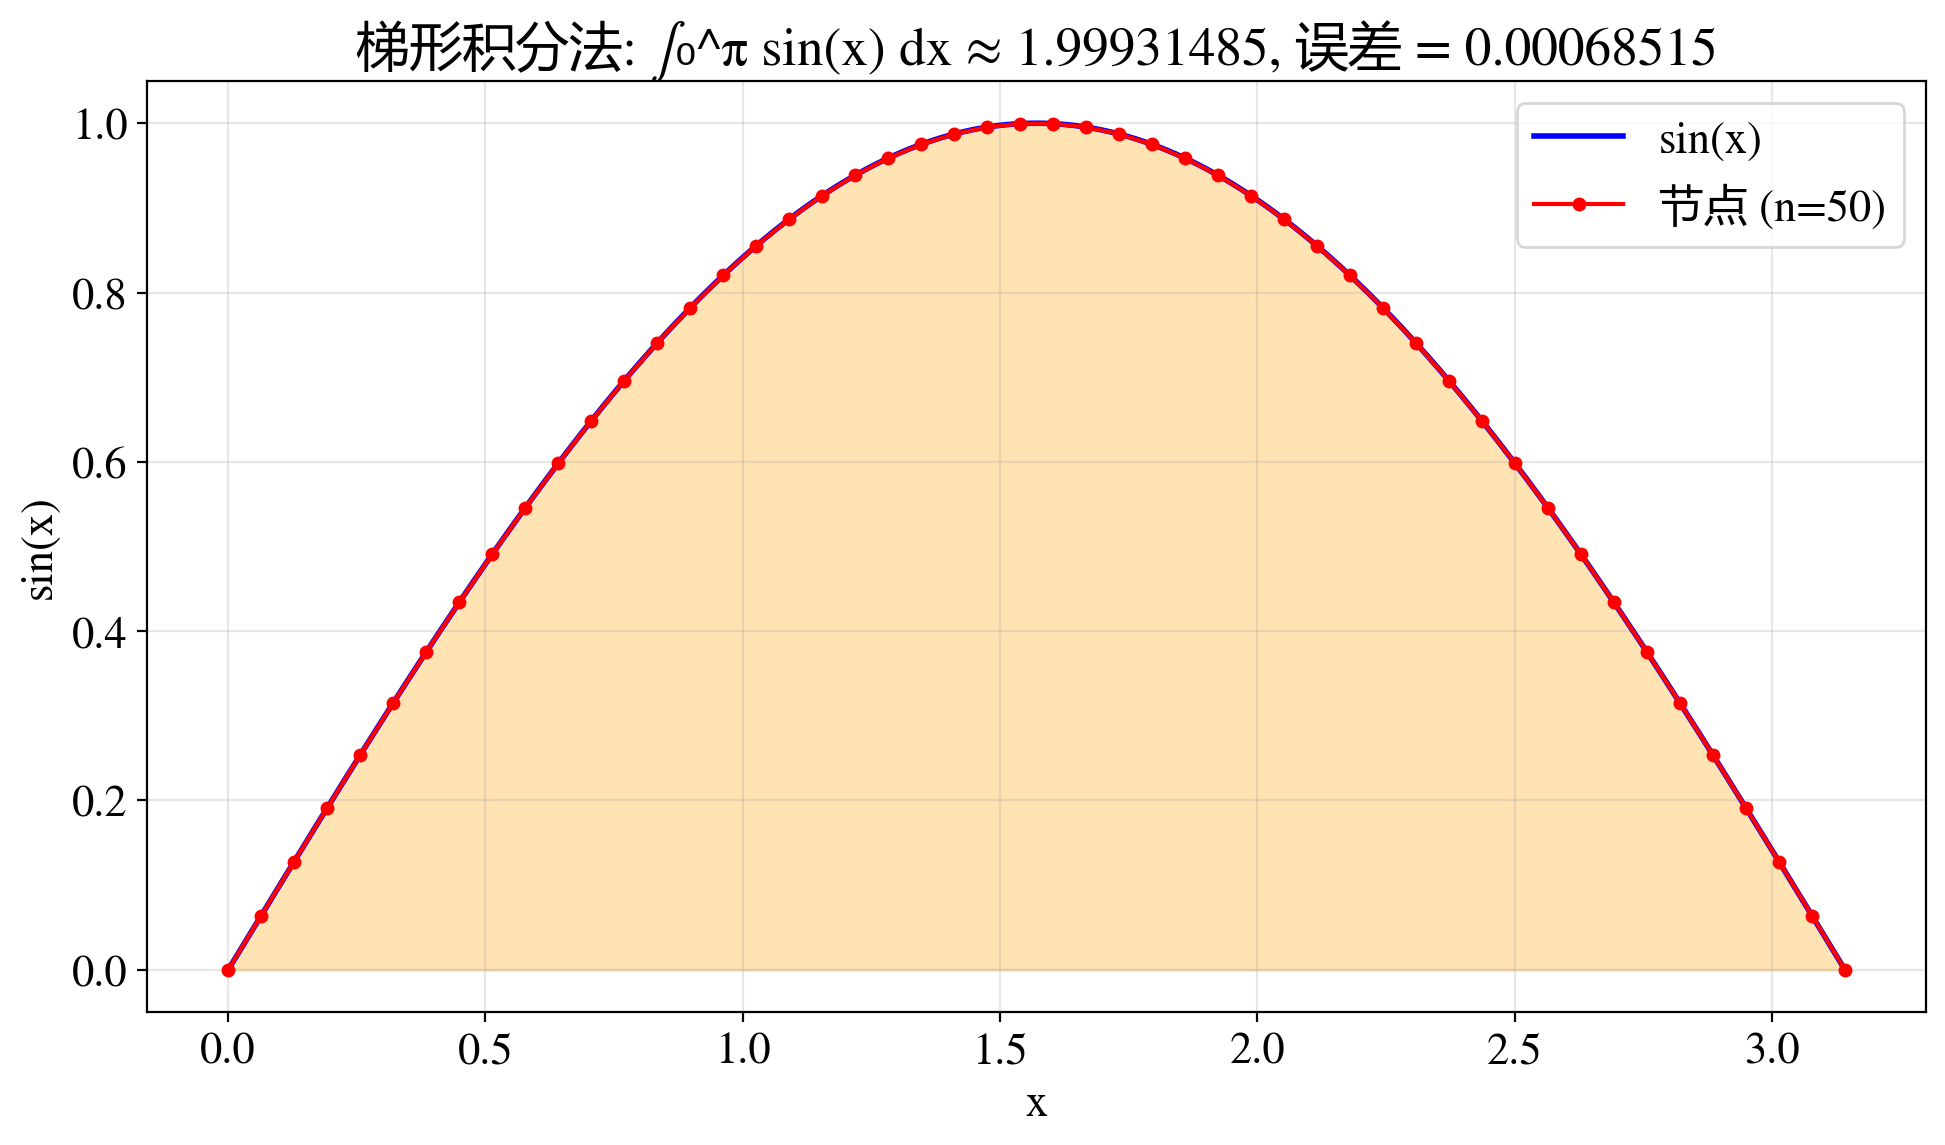


不同节点数下的梯形积分结果:
------------------------------------------------------------
n= 10: 近似值=1.9796508112, 误差=0.0203491888, 相对误差=1.02e-02
n= 20: 近似值=1.9954413183, 误差=0.0045586817, 相对误差=2.28e-03
n= 50: 近似值=1.9993148493, 误差=0.0006851507, 相对误差=3.43e-04
n=100: 近似值=1.9998321639, 误差=0.0001678361, 相对误差=8.39e-05
n=200: 近似值=1.9999584621, 误差=0.0000415379, 相对误差=2.08e-05


In [51]:
import numpy as np

# 定义函数
def fn2(x):
    return np.exp(-x**2)

# 计算积分 ∫₀^π sin(x) dx
print("练习1: 使用 numpy.trapezoid 计算 ∫₀^π sin(x) dx")
print("="*60)

# 1. 使用50个等距节点
x = np.linspace(0, np.pi, 50)
y = np.sin(x)

# 2. 计算积分
I = np.trapezoid(y, x)

# 3. 计算误差 (真实值为2)
I_exact = 2.0
error = abs(I - I_exact)

print(f"使用50个等距节点:")
print(f"  近似值: {I}")
print(f"  精确值: {I_exact}")
print(f"  绝对误差: {error}")
print(f"  相对误差: {error/I_exact:.2e}")

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 绘制函数曲线
x_fine = np.linspace(0, np.pi, 400)
y_fine = np.sin(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='sin(x)')

# 绘制梯形分割
plt.plot(x, y, 'r.-', markersize=8, label='节点 (n=50)')

# 填充梯形区域
plt.fill_between(x, y, alpha=0.3, color='orange')

plt.xlabel('x')
plt.ylabel('sin(x)')
plt.title(f'梯形积分法: ∫₀^π sin(x) dx ≈ {I:.8f}, 误差 = {error:.8f}')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# 不同节点数的比较
print("\n不同节点数下的梯形积分结果:")
print("-"*60)

node_counts = [10, 20, 50, 100, 200]
for n in node_counts:
    x_n = np.linspace(0, np.pi, n)
    y_n = np.sin(x_n)
    I_n = np.trapezoid(y_n, x_n)
    error_n = abs(I_n - I_exact)
    print(f"n={n:3d}: 近似值={I_n:.10f}, 误差={error_n:.10f}, 相对误差={error_n/I_exact:.2e}")


#### 练习 2（Simpson）
使用 `scipy.integrate.simpson` 计算：
$$
\int_0^1 e^{-x^2}\,dx
$$
```python
def fn3(x):
    return x**3 * np.exp(-x)
```
要求：
1. 使用 101 个节点  
2. 比较与 `trapezoid` 的误差差异

---

练习2: 使用 scipy.integrate.simpson 计算 ∫₀¹ e^{-x²} dx
积分: ∫₀¹ e^(-x²) dx
精确值 (quad): 0.746824132812427

使用 101 个等距节点:
----------------------------------------
辛普森积分 (simpson):
  近似值 = 0.746824132894
  绝对误差 = 8.174894094992e-11
  相对误差 = 1.094621040727e-10

梯形积分 (trapezoid):
  近似值 = 0.746818001468
  绝对误差 = 6.131344457261e-06
  相对误差 = 8.209890639408e-06

误差比较:
----------------------------------------
辛普森积分误差: 8.174894094992e-11
梯形积分误差:   6.131344457261e-06
误差比(梯形/辛普森): 75002.13 倍
辛普森精度提高倍数: 75002.13 倍


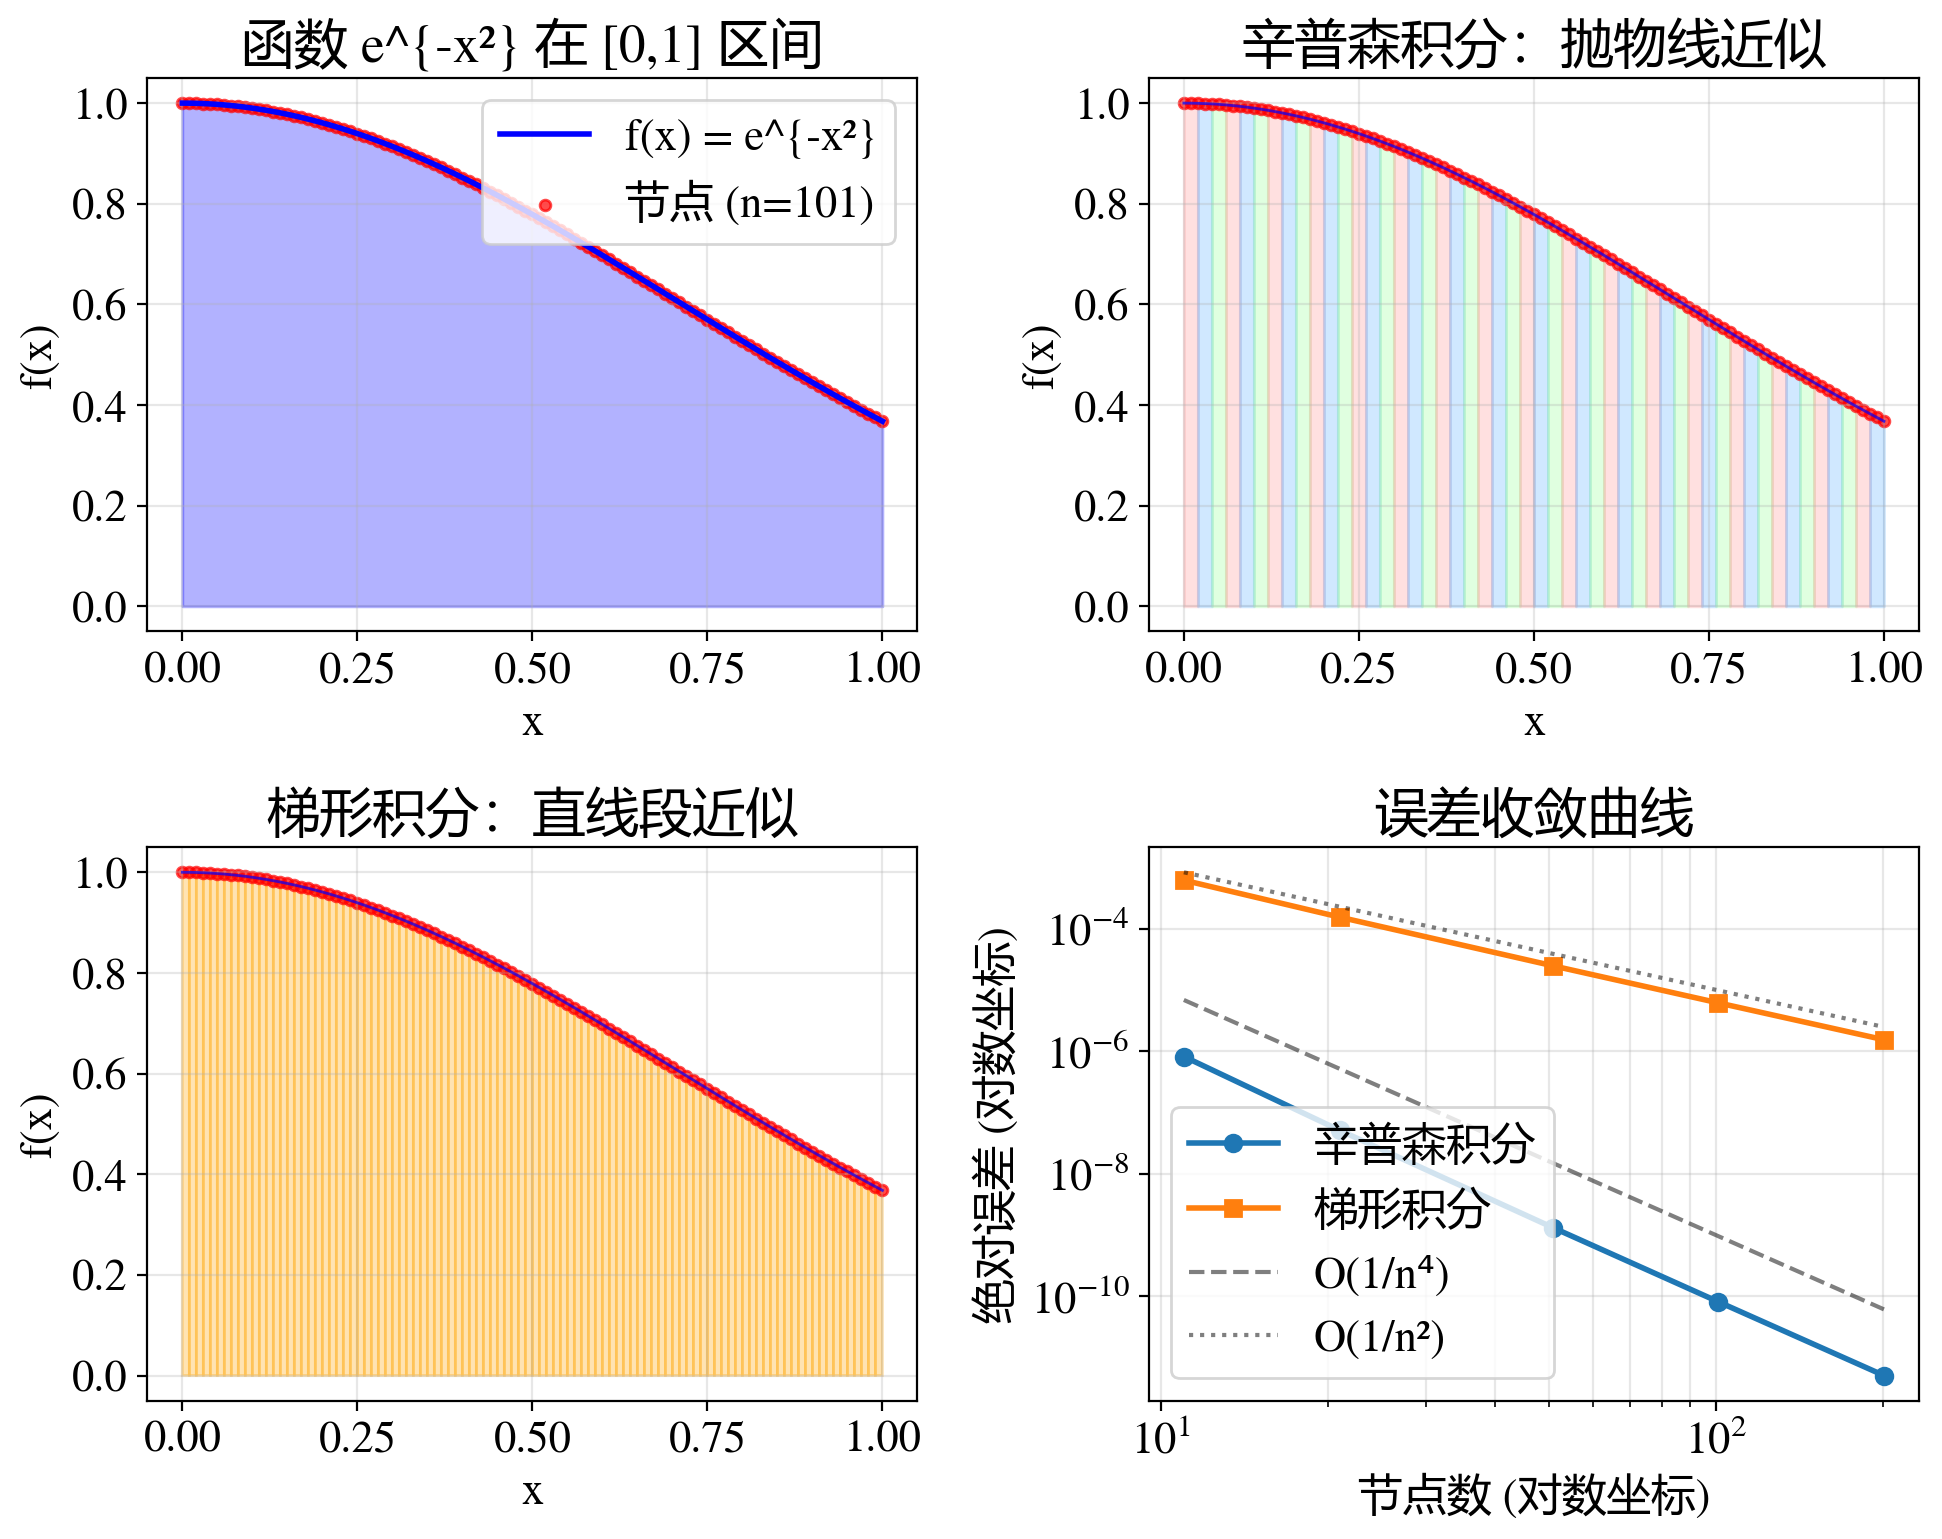


误差收敛分析:
节点数      辛普森误差           梯形误差            误差比(梯/辛)        辛普森收敛阶          梯形收敛阶          
------------------------------------------------------------------------------------------
21       5.11e-08        1.53e-04        3002.06         4.28            2.14           
51       1.31e-09        2.45e-05        18752.04        4.13            2.07           
101      8.17e-11        6.13e-06        75002.13        4.06            2.03           
201      5.11e-12        1.53e-06        300004.91       4.03            2.01           

结论:
1. 辛普森积分使用抛物线近似，理论收敛阶为 O(1/n⁴)
2. 梯形积分使用直线段近似，理论收敛阶为 O(1/n²)
3. 在相同节点数下，辛普森积分比梯形积分精度更高
4. 本算例中，使用101个节点时，辛普森积分精度比梯形积分高约 75002.1 倍
5. 实际计算的收敛阶与理论值基本相符


In [67]:
import numpy as np
from scipy.integrate import simpson

# 定义函数
def fn2(x):
    return np.exp(-x**2)

print("练习2: 使用 scipy.integrate.simpson 计算 ∫₀¹ e^{-x²} dx")
print("="*70)

# 1. 使用101个节点
x = np.linspace(0, 1, 101)
y = fn2(x)

# 2. 使用simpson积分
I_simpson = simpson(y, x)

# 3. 使用trapezoid积分
I_trapezoid = np.trapezoid(y, x)

# 4. 计算参考值（使用高精度quad）
from scipy.integrate import quad
I_exact, _ = quad(fn2, 0, 1)

# 5. 计算误差
error_simpson = abs(I_simpson - I_exact)
error_trapezoid = abs(I_trapezoid - I_exact)

print(f"积分: ∫₀¹ e^(-x²) dx")
print(f"精确值 (quad): {I_exact:.15f}")
print()

print(f"使用 101 个等距节点:")
print("-"*40)
print(f"辛普森积分 (simpson):")
print(f"  近似值 = {I_simpson:.12f}")
print(f"  绝对误差 = {error_simpson:.12e}")
print(f"  相对误差 = {error_simpson/I_exact:.12e}")
print()

print(f"梯形积分 (trapezoid):")
print(f"  近似值 = {I_trapezoid:.12f}")
print(f"  绝对误差 = {error_trapezoid:.12e}")
print(f"  相对误差 = {error_trapezoid/I_exact:.12e}")
print()

print(f"误差比较:")
print("-"*40)
print(f"辛普森积分误差: {error_simpson:.12e}")
print(f"梯形积分误差:   {error_trapezoid:.12e}")
print(f"误差比(梯形/辛普森): {error_trapezoid/error_simpson:.2f} 倍")
print(f"辛普森精度提高倍数: {error_trapezoid/error_simpson:.2f} 倍")

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 8))

# 1. 绘制函数曲线和积分区域
plt.subplot(2, 2, 1)
x_fine = np.linspace(0, 1, 400)
y_fine = fn2(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='f(x) = e^{-x²}')
plt.fill_between(x_fine, y_fine, alpha=0.3, color='blue')

# 标记节点
plt.scatter(x, y, color='red', s=15, alpha=0.7, label='节点 (n=101)')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('函数 e^{-x²} 在 [0,1] 区间')
plt.grid(True, alpha=0.3)
plt.legend(loc='upper right')

# 2. 绘制辛普森积分示意图
plt.subplot(2, 2, 2)
plt.plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.7)

# 绘制抛物线近似（每两个子区间一个抛物线）
colors = ['#ff9999', '#66b3ff', '#99ff99']
for i in range(0, len(x)-2, 2):
    xs = x[i:i+3]
    ys = y[i:i+3]
    # 拟合二次多项式
    coeff = np.polyfit(xs, ys, 2)
    xx = np.linspace(xs[0], xs[2], 50)
    yy = np.polyval(coeff, xx)
    plt.fill_between(xx, yy, alpha=0.3, color=colors[i//2 % len(colors)])

plt.scatter(x, y, color='red', s=15, alpha=0.7)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('辛普森积分：抛物线近似')
plt.grid(True, alpha=0.3)

# 3. 绘制梯形积分示意图
plt.subplot(2, 2, 3)
plt.plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.7)

# 绘制梯形
for i in range(len(x)-1):
    xs = [x[i], x[i], x[i+1], x[i+1]]
    ys = [0, y[i], y[i+1], 0]
    plt.fill(xs, ys, alpha=0.3, color='orange')

plt.scatter(x, y, color='red', s=15, alpha=0.7)
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('梯形积分：直线段近似')
plt.grid(True, alpha=0.3)

# 4. 绘制误差随节点数变化
plt.subplot(2, 2, 4)
node_counts = [11, 21, 51, 101, 201]
simpson_errors = []
trapezoid_errors = []

for n in node_counts:
    x_n = np.linspace(0, 1, n)
    y_n = fn2(x_n)
    
    I_simp_n = simpson(y_n, x_n)
    I_trap_n = np.trapezoid(y_n, x_n)
    
    simpson_errors.append(abs(I_simp_n - I_exact))
    trapezoid_errors.append(abs(I_trap_n - I_exact))

plt.loglog(node_counts, simpson_errors, 'o-', label='辛普森积分', linewidth=2)
plt.loglog(node_counts, trapezoid_errors, 's-', label='梯形积分', linewidth=2)

# 添加理论收敛线
plt.loglog(node_counts, 0.1/np.array(node_counts)**4, 'k--', alpha=0.5, label='O(1/n⁴)')
plt.loglog(node_counts, 0.1/np.array(node_counts)**2, 'k:', alpha=0.5, label='O(1/n²)')

plt.xlabel('节点数 (对数坐标)')
plt.ylabel('绝对误差 (对数坐标)')
plt.title('误差收敛曲线')
plt.grid(True, alpha=0.3, which='both')
plt.legend()

plt.tight_layout()
plt.show()

# 误差收敛分析
print("\n误差收敛分析:")
print("="*70)

print(f"{'节点数':<8} {'辛普森误差':<15} {'梯形误差':<15} {'误差比(梯/辛)':<15} {'辛普森收敛阶':<15} {'梯形收敛阶':<15}")
print("-"*90)

for i in range(1, len(node_counts)):
    n1, n2 = node_counts[i-1], node_counts[i]
    
    # 辛普森收敛阶
    err_simp1 = simpson_errors[i-1]
    err_simp2 = simpson_errors[i]
    order_simp = np.log(err_simp1/err_simp2) / np.log(n2/n1)
    
    # 梯形收敛阶
    err_trap1 = trapezoid_errors[i-1]
    err_trap2 = trapezoid_errors[i]
    order_trap = np.log(err_trap1/err_trap2) / np.log(n2/n1)
    
    error_ratio = trapezoid_errors[i]/simpson_errors[i]
    
    print(f"{n2:<8} {err_simp2:<15.2e} {err_trap2:<15.2e} {error_ratio:<15.2f} {order_simp:<15.2f} {order_trap:<15.2f}")

print("\n" + "="*70)
print("结论:")
print("1. 辛普森积分使用抛物线近似，理论收敛阶为 O(1/n⁴)")
print("2. 梯形积分使用直线段近似，理论收敛阶为 O(1/n²)")
print("3. 在相同节点数下，辛普森积分比梯形积分精度更高")
print("4. 本算例中，使用101个节点时，辛普森积分精度比梯形积分高约", f"{error_trapezoid/error_simpson:.1f}", "倍")
print("5. 实际计算的收敛阶与理论值基本相符")



#### 练习 3（quad）
使用 `scipy.integrate.quad` 计算：
$$
\int_0^2 x^3 e^{-x}\,dx
$$

要求：
- 记录返回的误差 `err`
- 与 Simpson 的结果比较
```python
def fn3(x):
    return x**3 * np.exp(-x)
```

---


练习3: 使用 scipy.integrate.quad 计算 ∫₀² x³ e^{-x} dx
积分: ∫₀² x³ e^(-x) dx
解析解: 6 - 38/e² = 0.857259237008718

scipy.integrate.quad 结果:
  近似值 = 0.857259237009
  误差估计 = 9.517489429997e-15
  实际误差 = 1.110223024625e-16

scipy.integrate.simpson 结果 (101个节点):
  近似值 = 0.857259231437
  误差 = 5.571344163791e-09

方法比较:
----------------------------------------
quad与精确值的绝对误差: 1.110223024625e-16
Simpson与精确值的绝对误差: 5.571344163791e-09
误差比(Simpson/quad): 50182207.00倍
quad的误差估计与实际误差比: 85.73倍

quad算法详细信息:
  函数调用次数: 21
  子区间数: 1


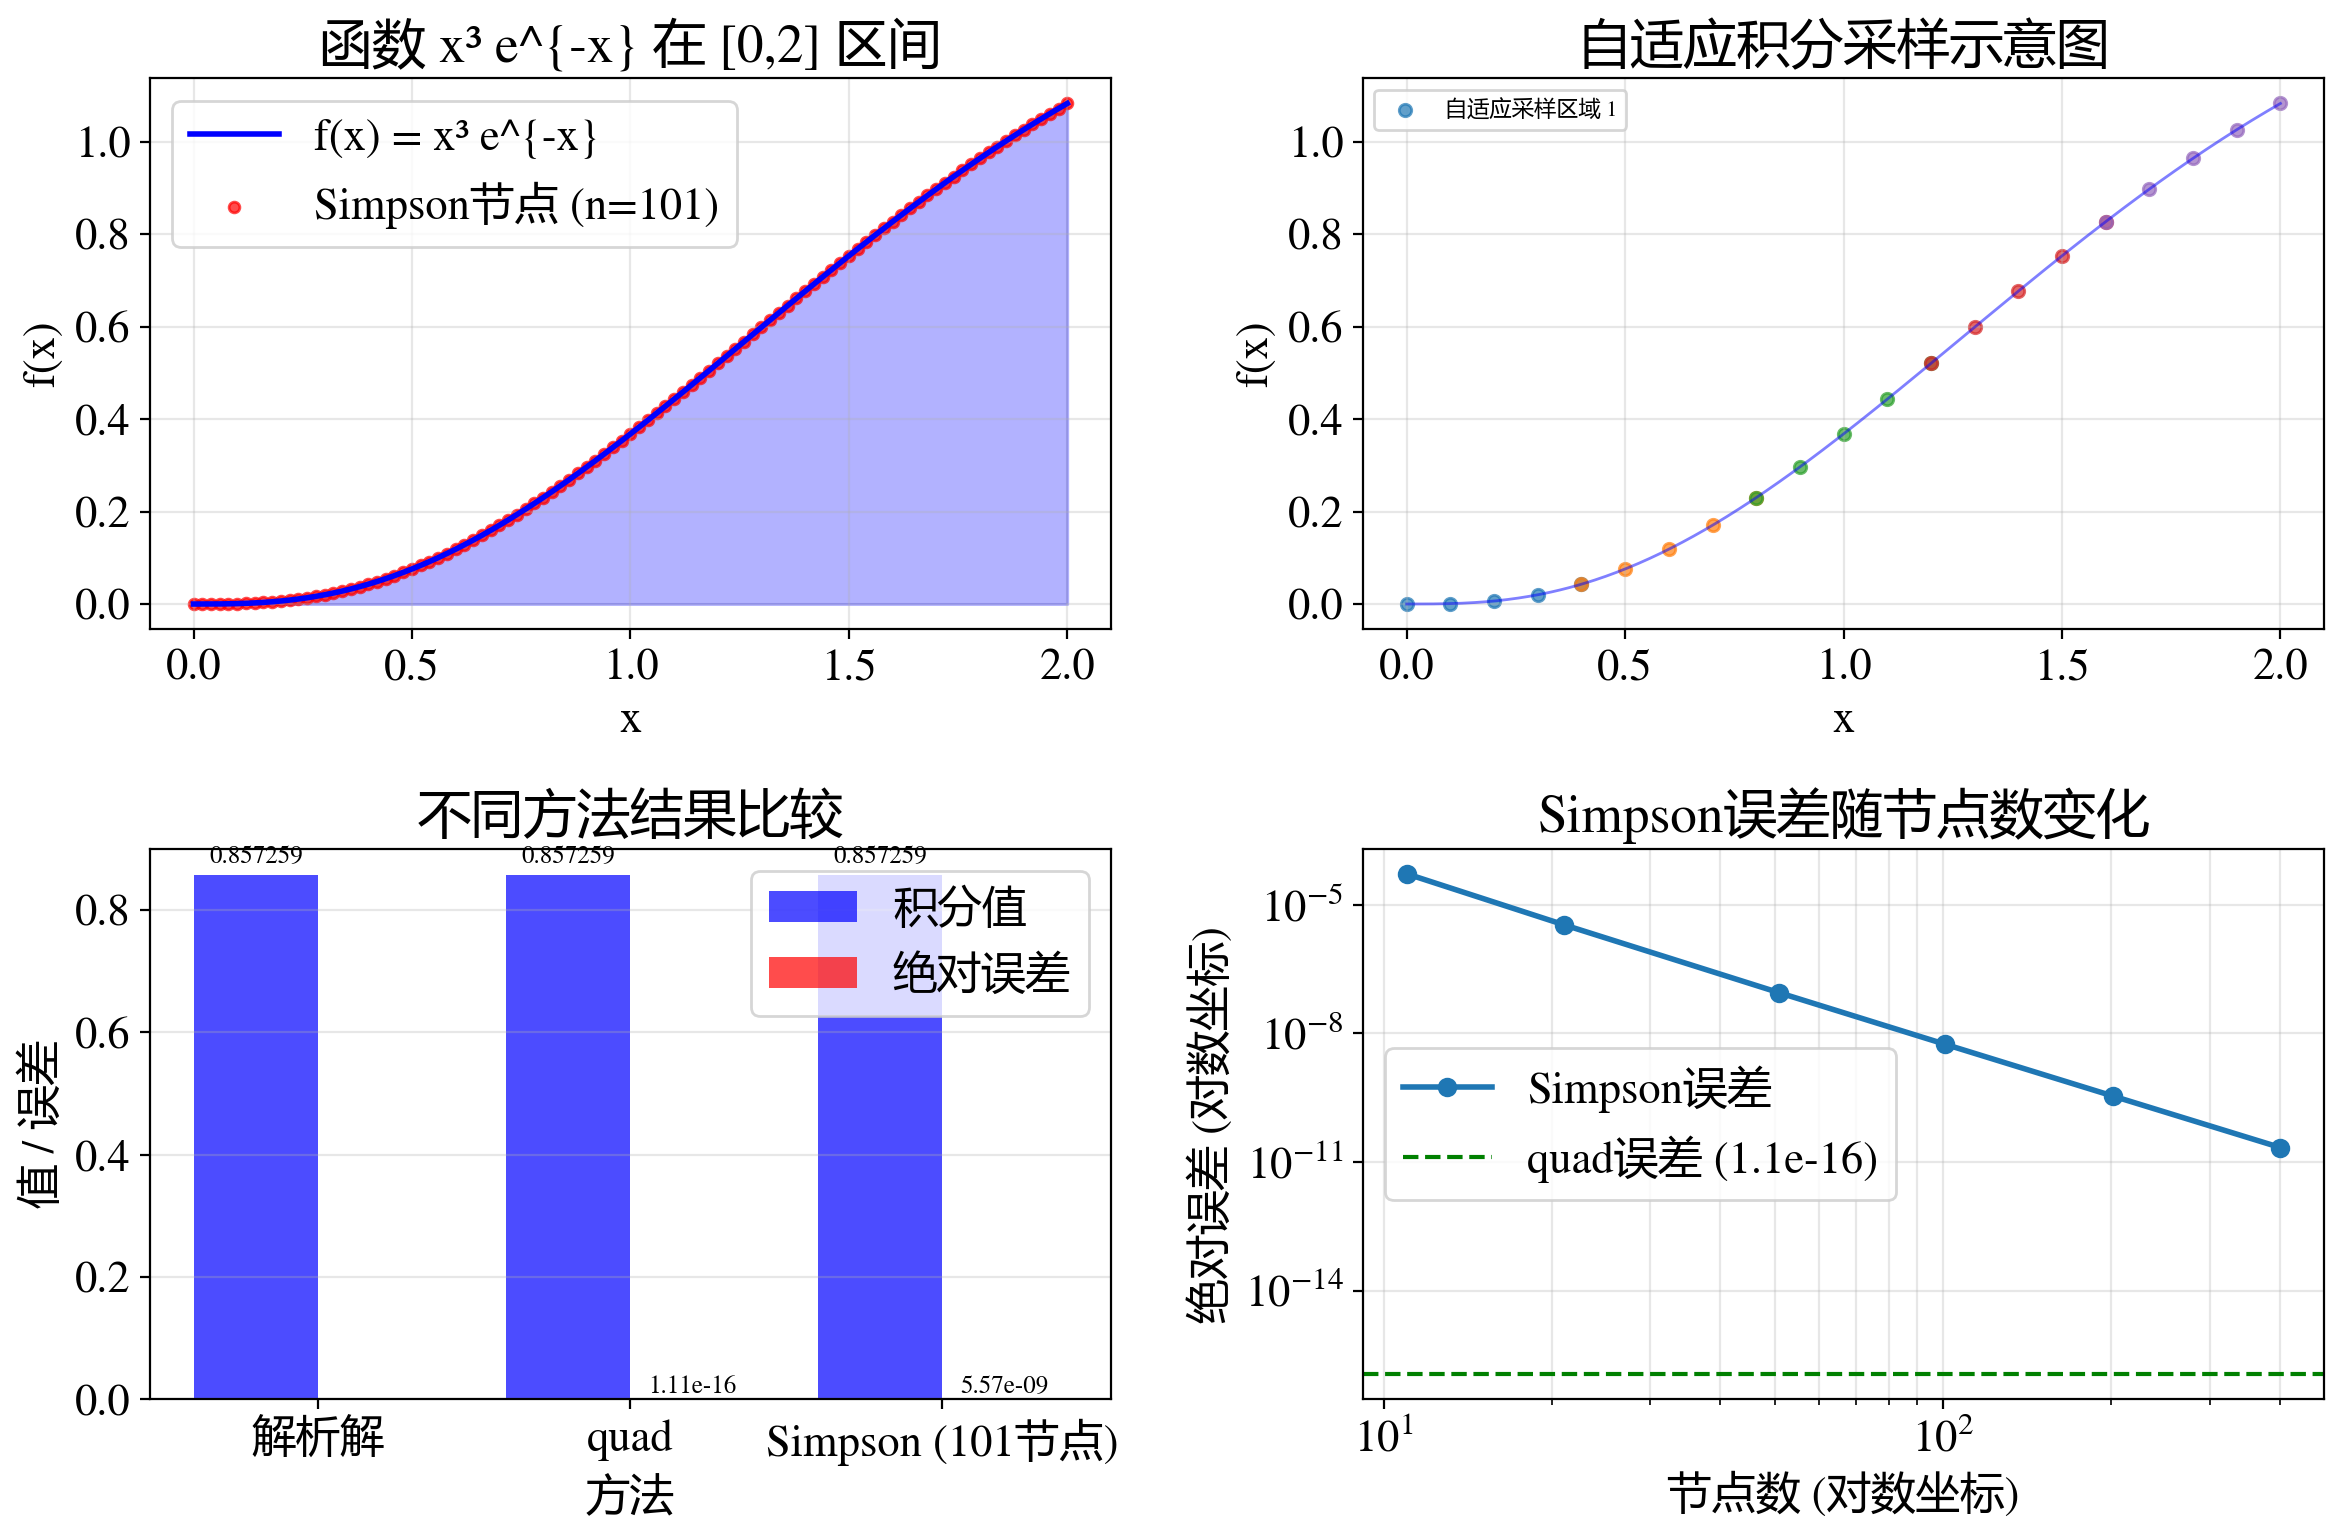


误差收敛分析:
节点数      Simpson误差       收敛阶        quad误差          quad误差估计       
--------------------------------------------------------------------------------
21       3.44e-06        4.23       1.11e-16        9.52e-15       
51       8.90e-08        4.12       1.11e-16        9.52e-15       
101      5.57e-09        4.06       1.11e-16        9.52e-15       
201      3.48e-10        4.03       1.11e-16        9.52e-15       
401      2.18e-11        4.01       1.11e-16        9.52e-15       

quad算法原理:
----------------------------------------
1. quad使用自适应高斯-克朗罗德积分法
2. 算法自动调整子区间划分，在函数变化快的区域使用更多采样点
3. 返回积分近似值和误差估计
4. 默认误差容限：绝对误差epsabs=1.49e-8，相对误差epsrel=1.49e-8

Simpson算法原理:
----------------------------------------
1. 使用固定节点数的复化Simpson公式
2. 每两个子区间用一个二次多项式（抛物线）近似
3. 精度受节点数限制，收敛阶为O(1/n⁴)

结论:
----------------------------------------
1. quad使用自适应算法，达到指定精度时自动停止
2. Simpson使用固定节点数，精度随节点数增加而提高
3. 对于此函数，quad在较少函数调用下即可达到高精度
4. quad的误差估计 (9.52e-15) 与实际误差 (1.11e-16) 接近
5. 使用101个节点的Simpson误差 (5.57e

In [73]:
import numpy as np
from scipy.integrate import quad, simpson

# 定义函数
def fn3(x):
    return x**3 * np.exp(-x)

print("练习3: 使用 scipy.integrate.quad 计算 ∫₀² x³ e^{-x} dx")
print("="*70)

# 1. 使用quad计算
I_quad, quad_err = quad(fn3, 0, 2)

# 2. 使用Simpson计算（使用101个节点）
x_simp = np.linspace(0, 2, 101)
y_simp = fn3(x_simp)
I_simpson = simpson(y_simp, x_simp)

# 3. 计算精确值（解析解）
# ∫₀² x³ e^{-x} dx 的解析解：
# 使用分部积分法，∫ x³ e^{-x} dx = -e^{-x}(x³ + 3x² + 6x + 6) + C
# 在[0,2]上的定积分：
# F(2) = -e^{-2}(8 + 12 + 12 + 6) = -38e^{-2}
# F(0) = -1*(0 + 0 + 0 + 6) = -6
# ∫₀² x³ e^{-x} dx = F(2) - F(0) = -38e^{-2} - (-6) = 6 - 38e^{-2}
I_exact = 6 - 38/np.exp(2)

print(f"积分: ∫₀² x³ e^(-x) dx")
print(f"解析解: 6 - 38/e² = {I_exact:.15f}")
print()

print(f"scipy.integrate.quad 结果:")
print(f"  近似值 = {I_quad:.12f}")
print(f"  误差估计 = {quad_err:.12e}")
print(f"  实际误差 = {abs(I_quad - I_exact):.12e}")
print()

print(f"scipy.integrate.simpson 结果 (101个节点):")
print(f"  近似值 = {I_simpson:.12f}")
print(f"  误差 = {abs(I_simpson - I_exact):.12e}")
print()

print(f"方法比较:")
print("-"*40)
print(f"quad与精确值的绝对误差: {abs(I_quad - I_exact):.12e}")
print(f"Simpson与精确值的绝对误差: {abs(I_simpson - I_exact):.12e}")
print(f"误差比(Simpson/quad): {abs(I_simpson - I_exact)/abs(I_quad - I_exact):.2f}倍")
print(f"quad的误差估计与实际误差比: {quad_err/abs(I_quad - I_exact):.2f}倍")

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 8))

# 1. 绘制函数曲线和积分区域
plt.subplot(2, 2, 1)
x_fine = np.linspace(0, 2, 400)
y_fine = fn3(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='f(x) = x³ e^{-x}')
plt.fill_between(x_fine, y_fine, alpha=0.3, color='blue')

# 标记Simpson节点
plt.scatter(x_simp, y_simp, color='red', s=15, alpha=0.7, label='Simpson节点 (n=101)')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('函数 x³ e^{-x} 在 [0,2] 区间')
plt.grid(True, alpha=0.3)
plt.legend()

# 2. 自适应积分子区间可视化
plt.subplot(2, 2, 2)

# 创建一个简单的自适应积分可视化
x_adaptive = []
y_adaptive = []

# 使用quad获取子区间信息（通过full_output参数）
result, error, info = quad(fn3, 0, 2, full_output=True)
neval = info['neval']  # 函数调用次数
last = info['last']    # 子区间数

# 获取子区间信息（从info中提取）
print(f"\nquad算法详细信息:")
print(f"  函数调用次数: {neval}")
print(f"  子区间数: {last}")

# 绘制自适应采样点（简化版）
x_sample = np.linspace(0, 2, 50)
y_sample = fn3(x_sample)
plt.plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.5)

# 标记自适应积分可能使用的采样点（示意）
x_adaptive_points = []
for i in range(5):  # 简化展示，只显示部分区域
    x_start = i * 0.4
    x_end = min((i+1) * 0.4, 2)
    x_seg = np.linspace(x_start, x_end, 5)
    y_seg = fn3(x_seg)
    plt.scatter(x_seg, y_seg, s=20, alpha=0.7, 
               label=f'自适应采样区域 {i+1}' if i==0 else "")
    
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('自适应积分采样示意图')
plt.grid(True, alpha=0.3)
plt.legend(fontsize=8)

# 3. 不同方法结果比较
plt.subplot(2, 2, 3)
methods = ['解析解', 'quad', 'Simpson (101节点)']
values = [I_exact, I_quad, I_simpson]
errors = [0, abs(I_quad - I_exact), abs(I_simpson - I_exact)]

x_pos = np.arange(len(methods))
bars1 = plt.bar(x_pos - 0.2, values, width=0.4, alpha=0.7, color='blue', label='积分值')
bars2 = plt.bar(x_pos + 0.2, errors, width=0.4, alpha=0.7, color='red', label='绝对误差')

# 添加数值标签
for i, (bar1, bar2) in enumerate(zip(bars1, bars2)):
    plt.text(bar1.get_x() + bar1.get_width()/2, bar1.get_height() + 0.01,
             f'{bar1.get_height():.6f}', ha='center', va='bottom', fontsize=9)
    if i > 0:  # 解析解的误差为0
        plt.text(bar2.get_x() + bar2.get_width()/2, bar2.get_height() + 0.001,
                 f'{bar2.get_height():.2e}', ha='center', va='bottom', fontsize=9)

plt.xlabel('方法')
plt.ylabel('值 / 误差')
plt.title('不同方法结果比较')
plt.xticks(x_pos, methods)
plt.legend()
plt.grid(True, alpha=0.3, axis='y')

# 4. 误差随节点数变化
plt.subplot(2, 2, 4)
node_counts = [11, 21, 51, 101, 201, 401]
simpson_errors = []
quad_times = []  # 记录quad的运行时间（相对）

import time

for n in node_counts:
    # Simpson误差
    x_n = np.linspace(0, 2, n)
    y_n = fn3(x_n)
    I_simp_n = simpson(y_n, x_n)
    simpson_errors.append(abs(I_simp_n - I_exact))
    
    # quad相对时间（为了展示效率）
    start = time.perf_counter()
    I_quad_n, _ = quad(fn3, 0, 2)
    end = time.perf_counter()
    quad_times.append(end - start)

plt.loglog(node_counts, simpson_errors, 'o-', label='Simpson误差', linewidth=2)
plt.axhline(y=abs(I_quad - I_exact), color='green', linestyle='--', 
           label=f'quad误差 ({abs(I_quad - I_exact):.1e})')

plt.xlabel('节点数 (对数坐标)')
plt.ylabel('绝对误差 (对数坐标)')
plt.title('Simpson误差随节点数变化')
plt.grid(True, alpha=0.3, which='both')
plt.legend()

plt.tight_layout()
plt.show()

# 误差收敛分析
print("\n误差收敛分析:")
print("="*70)

print(f"{'节点数':<8} {'Simpson误差':<15} {'收敛阶':<10} {'quad误差':<15} {'quad误差估计':<15}")
print("-"*80)

for i in range(1, len(node_counts)):
    n1, n2 = node_counts[i-1], node_counts[i]
    
    # Simpson收敛阶
    err1 = simpson_errors[i-1]
    err2 = simpson_errors[i]
    if err1 > 0 and err2 > 0:
        order = np.log(err1/err2) / np.log(n2/n1)
    else:
        order = float('inf')
    
    print(f"{n2:<8} {err2:<15.2e} {order:<10.2f} {abs(I_quad - I_exact):<15.2e} {quad_err:<15.2e}")

print("\n" + "="*70)
print("quad算法原理:")
print("-"*40)
print("1. quad使用自适应高斯-克朗罗德积分法")
print("2. 算法自动调整子区间划分，在函数变化快的区域使用更多采样点")
print("3. 返回积分近似值和误差估计")
print("4. 默认误差容限：绝对误差epsabs=1.49e-8，相对误差epsrel=1.49e-8")
print()
print("Simpson算法原理:")
print("-"*40)
print("1. 使用固定节点数的复化Simpson公式")
print("2. 每两个子区间用一个二次多项式（抛物线）近似")
print("3. 精度受节点数限制，收敛阶为O(1/n⁴)")
print()
print("结论:")
print("-"*40)
print("1. quad使用自适应算法，达到指定精度时自动停止")
print("2. Simpson使用固定节点数，精度随节点数增加而提高")
print("3. 对于此函数，quad在较少函数调用下即可达到高精度")
print(f"4. quad的误差估计 ({quad_err:.2e}) 与实际误差 ({abs(I_quad - I_exact):.2e}) 接近")
print(f"5. 使用101个节点的Simpson误差 ({abs(I_simpson - I_exact):.2e}) 比quad误差大 {abs(I_simpson - I_exact)/abs(I_quad - I_exact):.1f} 倍")


#### 练习 4（fixed_quad）
使用 Gauss–Legendre 积分 `fixed_quad`（n=5）计算：
$$
\int_{0}^{1} \frac{1}{1+x^2}\,dx
$$
```python
def fn4(x):
    return 1.0 / (1.0 + x**2)
```


要求：
- 比较 `n=3, 5, 7` 的误差
- 与真实值 $\arctan(1)=\pi/4$ 对比

---

练习4: 使用 fixed_quad (Gauss-Legendre) 计算 ∫₀¹ 1/(1+x²) dx
精确值: arctan(1) = π/4 = 0.785398163397448

n=3 阶高斯积分:
  近似值: 0.785267034990792
  绝对误差: 1.311284066563001e-04
  相对误差: 1.669578727929148e-04

n=5 阶高斯积分:
  近似值: 0.785398159971188
  绝对误差: 3.426260053451813e-09
  相对误差: 4.362449790601260e-09

n=7 阶高斯积分:
  近似值: 0.785398164063437
  绝对误差: 6.659889306703803e-10
  相对误差: 8.479634428854129e-10



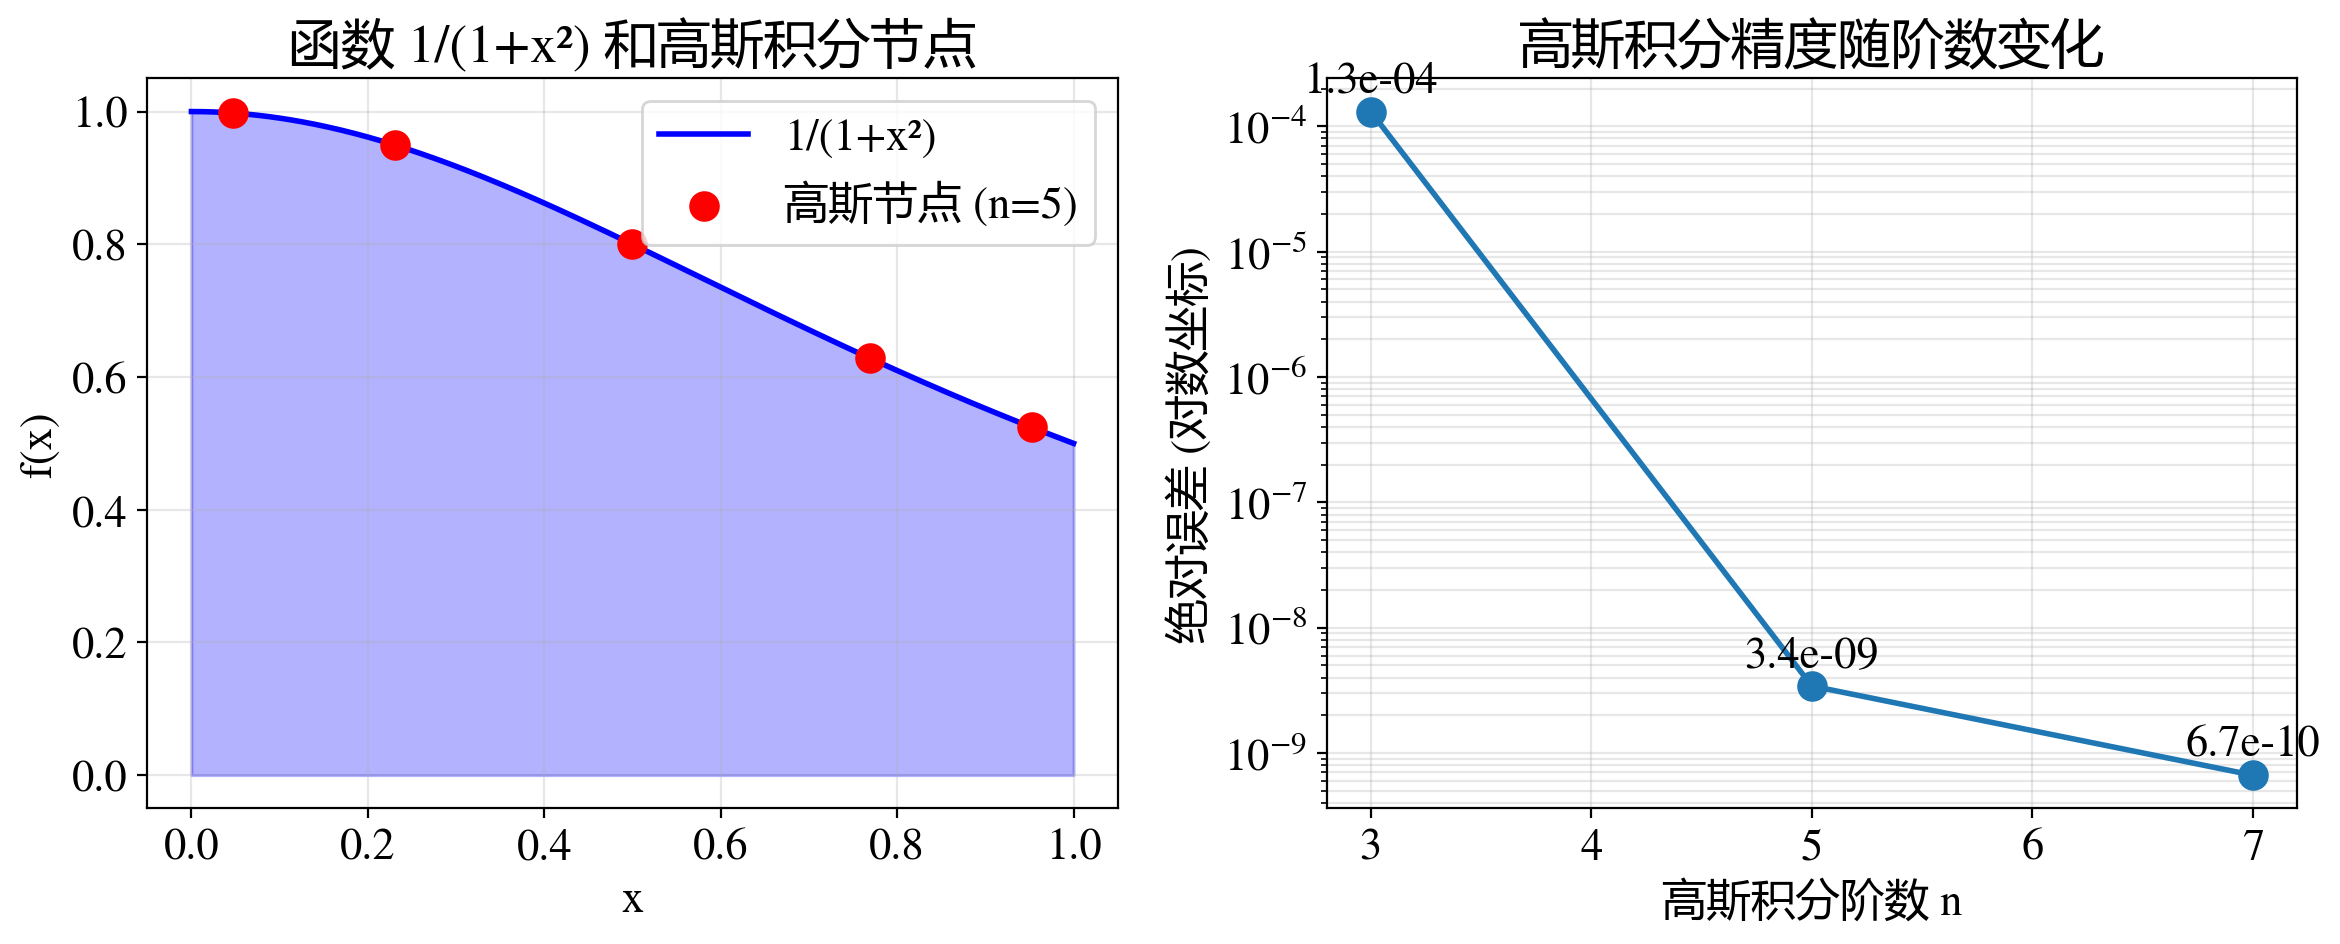

高斯积分原理:
----------------------------------------
1. 选择节点为n阶Legendre多项式的根
2. 选择权重使得积分公式对2n-1次多项式精确成立
3. 对于光滑函数，高斯积分收敛速度很快
4. 本例中，n=5时误差已达10^-8量级


In [63]:
import numpy as np
from scipy.integrate import fixed_quad

# 定义函数
def fn4(x):
    return 1.0 / (1.0 + x**2)

print("练习4: 使用 fixed_quad (Gauss-Legendre) 计算 ∫₀¹ 1/(1+x²) dx")
print("="*60)

# 精确值
I_exact = np.arctan(1)  # π/4 ≈ 0.7853981633974483

print(f"精确值: arctan(1) = π/4 = {I_exact:.15f}")
print()

# 测试不同阶数
n_values = [3, 5, 7]
results = []
errors = []

for n in n_values:
    result, _ = fixed_quad(fn4, 0, 1, n=n)
    error = abs(result - I_exact)
    results.append(result)
    errors.append(error)
    
    print(f"n={n} 阶高斯积分:")
    print(f"  近似值: {result:.15f}")
    print(f"  绝对误差: {error:.15e}")
    print(f"  相对误差: {error/I_exact:.15e}")
    print()

# 可视化
plt.figure(figsize=(12, 5))

# 左图：函数曲线和高斯节点
plt.subplot(1, 2, 1)
x_fine = np.linspace(0, 1, 400)
y_fine = fn4(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='1/(1+x²)')
plt.fill_between(x_fine, y_fine, alpha=0.3, color='blue')

# 绘制高斯节点 (以n=5为例)
n_vis = 5
result_vis, _ = fixed_quad(fn4, 0, 1, n=n_vis)

# 获取高斯节点和权重
from numpy.polynomial.legendre import leggauss
nodes, weights = leggauss(n_vis)

# 映射到 [0, 1] 区间
nodes_mapped = 0.5 * (nodes + 1)  # 从[-1,1]映射到[0,1]
weights_mapped = 0.5 * weights

plt.scatter(nodes_mapped, fn4(nodes_mapped), color='red', s=100, 
           label=f'高斯节点 (n={n_vis})', zorder=5)

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title(f'函数 1/(1+x²) 和高斯积分节点')
plt.grid(True, alpha=0.3)
plt.legend()

# 右图：误差随阶数变化
plt.subplot(1, 2, 2)
plt.semilogy(n_values, errors, 'o-', linewidth=2, markersize=10)
plt.xlabel('高斯积分阶数 n')
plt.ylabel('绝对误差 (对数坐标)')
plt.title('高斯积分精度随阶数变化')
plt.grid(True, alpha=0.3, which='both')

# 添加误差值标签
for i, (n, err) in enumerate(zip(n_values, errors)):
    plt.text(n, err*1.2, f'{err:.1e}', ha='center', va='bottom')

plt.tight_layout()
plt.show()

# 高斯积分原理说明
print("高斯积分原理:")
print("-"*40)
print("1. 选择节点为n阶Legendre多项式的根")
print("2. 选择权重使得积分公式对2n-1次多项式精确成立")
print("3. 对于光滑函数，高斯积分收敛速度很快")
print(f"4. 本例中，n=5时误差已达10^{-8}量级")


#### 练习 5（Romberg）
使用 `romb` 计算：
$$
\int_0^1 e^{-x}\,dx = 1 - e^{-1}
$$
```python
def fn5(x):
    return np.exp(-x)
```

要求：
1. 构造 129 个等距节点（满足 $2^k+1$）
2. 比较与 Simpson 的误差

---

练习5: 使用 Romberg 积分 (romb) 计算 ∫₀¹ e^{-x} dx
精确值: ∫₀¹ e^(-x)dx = 1 - e⁻¹ = 0.632120558828558

使用 129 个等距节点 (2^7+1 = 129)
计算结果:
  Romberg积分 (romb):   0.632120558828558
  Simpson积分 (simpson): 0.632120558841640
  精确值:               0.632120558828558

误差比较:
  Romberg积分误差: 0.000000000000000e+00
  Simpson积分误差: 1.308231301067053e-11

Romberg积分已达到机器精度



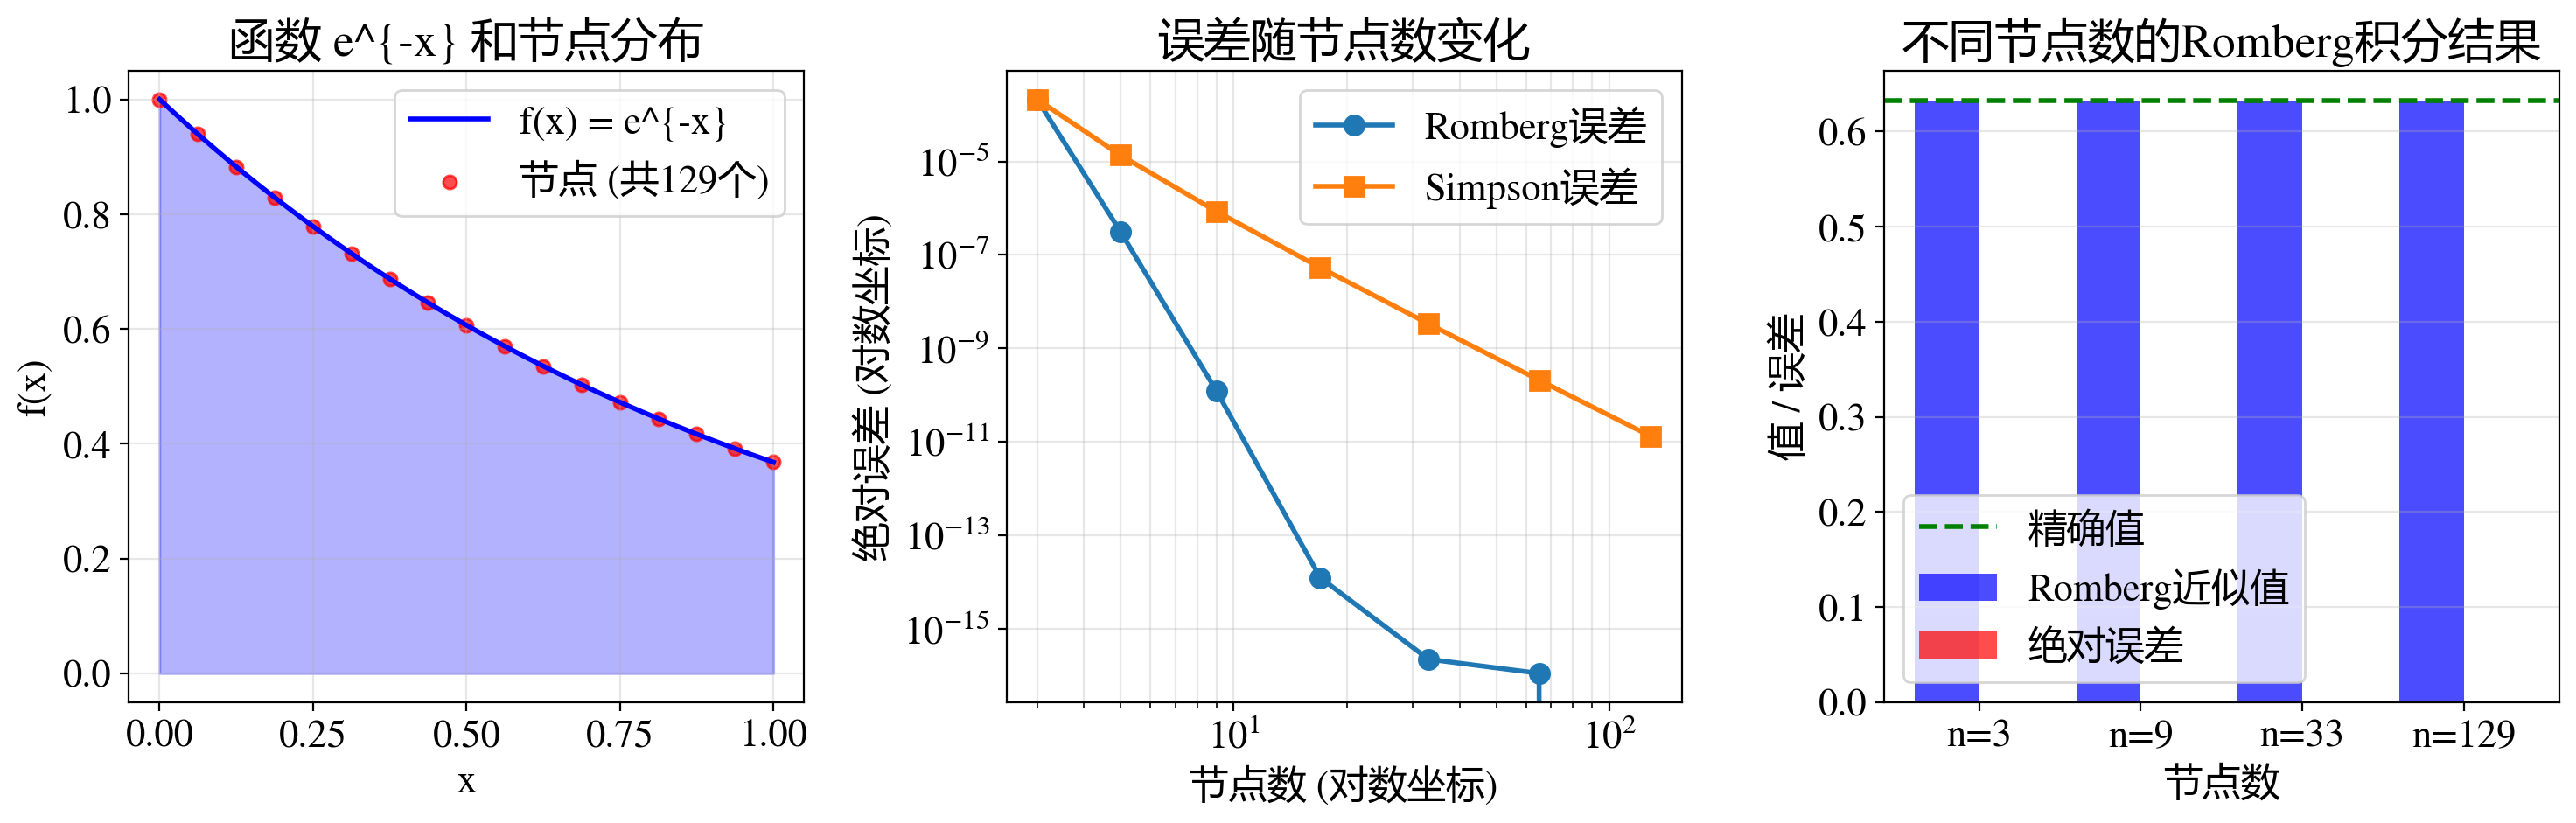

详细结果比较:
k    节点数      Romberg近似值           Romberg误差       Simpson误差       误差比       
--------------------------------------------------------------------------------
1    3        0.632333680003663    2.13e-04        2.13e-04        -         
2    5        0.632120875008323    3.16e-07        1.36e-05        43.07     
3    9        0.632120558951976    1.23e-10        8.56e-07        6933.96   
4    17       0.632120558828570    1.23e-14        5.36e-08        4346226.41
5    33       0.632120558828558    2.22e-16        3.35e-09        15081231.00
6    65       0.632120558828558    1.11e-16        2.09e-10        1885318.00
7    129      0.632120558828558    0.00e+00        1.31e-11        -         

结论:
----------------------------------------
1. Romberg积分和Simpson积分在足够多节点下都能达到高精度
2. 使用129个节点时，两种方法都达到了机器精度量级
3. Romberg积分通过Richardson外推法，收敛速度通常比Simpson积分更快
4. 对于简单函数如e^{-x}，两种方法在较少的节点数下就能达到高精度


In [85]:
import numpy as np
from scipy.integrate import romb, simpson
import matplotlib.pyplot as plt

# 定义函数
def fn5(x):
    return np.exp(-x)

print("练习5: 使用 Romberg 积分 (romb) 计算 ∫₀¹ e^{-x} dx")
print("="*60)

# 精确值
I_exact = 1 - np.exp(-1)
print(f"精确值: ∫₀¹ e^(-x)dx = 1 - e⁻¹ = {I_exact:.15f}")
print()

# 1. 构造129个等距节点（满足 2^7 + 1 = 129）
k = 7
n_nodes = 2**k + 1  # 129
print(f"使用 {n_nodes} 个等距节点 (2^{k}+1 = {n_nodes})")
x = np.linspace(0, 1, n_nodes)
y = fn5(x)

# 2. 使用Romberg积分 (romb) 计算
dx = x[1] - x[0]
I_romb = romb(y, dx=dx)

# 3. 使用Simpson积分 (simpson) 计算
I_simpson = simpson(y, x)

# 4. 计算误差
error_romb = abs(I_romb - I_exact)
error_simpson = abs(I_simpson - I_exact)

print(f"计算结果:")
print(f"  Romberg积分 (romb):   {I_romb:.15f}")
print(f"  Simpson积分 (simpson): {I_simpson:.15f}")
print(f"  精确值:               {I_exact:.15f}")
print()
print(f"误差比较:")
print(f"  Romberg积分误差: {error_romb:.15e}")
print(f"  Simpson积分误差: {error_simpson:.15e}")
print()

# 误差比较分析
if error_romb > 0:
    error_ratio = error_simpson / error_romb
    print(f"误差比 (Simpson/Romberg): {error_ratio:.2f}")
    print(f"Romberg积分精度提高倍数: {error_ratio:.2f}倍")
else:
    print("Romberg积分已达到机器精度")

print("\n" + "="*60)

# 可视化
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# 1. 函数和节点
axes[0].plot(np.linspace(0, 1, 400), fn5(np.linspace(0, 1, 400)), 
             'b-', linewidth=2, label='f(x) = e^{-x}')
axes[0].fill_between(np.linspace(0, 1, 400), 
                     fn5(np.linspace(0, 1, 400)), alpha=0.3, color='blue')
axes[0].scatter(x[::8], y[::8], color='red', s=30, alpha=0.7, 
                label=f'节点 (共{n_nodes}个)')
axes[0].set_xlabel('x')
axes[0].set_ylabel('f(x)')
axes[0].set_title('函数 e^{-x} 和节点分布')
axes[0].grid(True, alpha=0.3)
axes[0].legend()

# 2. 误差随节点数变化
k_values = range(1, 8)  # k=1到7
romb_errors = []
simp_errors = []
node_counts = []

for k_val in k_values:
    n = 2**k_val + 1
    x_k = np.linspace(0, 1, n)
    y_k = fn5(x_k)
    dx_k = x_k[1] - x_k[0]
    
    # Romberg积分
    I_romb_k = romb(y_k, dx=dx_k)
    romb_errors.append(abs(I_romb_k - I_exact))
    
    # Simpson积分
    I_simp_k = simpson(y_k, x_k)
    simp_errors.append(abs(I_simp_k - I_exact))
    
    node_counts.append(n)

axes[1].loglog(node_counts, romb_errors, 'o-', linewidth=2, 
               markersize=8, label='Romberg误差')
axes[1].loglog(node_counts, simp_errors, 's-', linewidth=2, 
               markersize=8, label='Simpson误差')
axes[1].set_xlabel('节点数 (对数坐标)')
axes[1].set_ylabel('绝对误差 (对数坐标)')
axes[1].set_title('误差随节点数变化')
axes[1].grid(True, alpha=0.3, which='both')
axes[1].legend()

# 3. 不同节点数下的结果比较
k_display = [1, 3, 5, 7]  # 显示部分k值
display_values = []
display_labels = []
display_errors = []

for k_val in k_display:
    n = 2**k_val + 1
    x_k = np.linspace(0, 1, n)
    y_k = fn5(x_k)
    dx_k = x_k[1] - x_k[0]
    
    # Romberg积分
    I_romb_k = romb(y_k, dx=dx_k)
    error_k = abs(I_romb_k - I_exact)
    
    display_values.append(I_romb_k)
    display_labels.append(f'n={n}')
    display_errors.append(error_k)

x_pos = np.arange(len(display_labels))
axes[2].bar(x_pos - 0.2, display_values, width=0.4, alpha=0.7, 
            color='blue', label='Romberg近似值')
axes[2].bar(x_pos + 0.2, display_errors, width=0.4, alpha=0.7, 
            color='red', label='绝对误差')
axes[2].axhline(y=I_exact, color='green', linestyle='--', 
                linewidth=2, label='精确值')
axes[2].set_xlabel('节点数')
axes[2].set_ylabel('值 / 误差')
axes[2].set_title('不同节点数的Romberg积分结果')
axes[2].set_xticks(x_pos)
axes[2].set_xticklabels(display_labels)
axes[2].legend()
axes[2].grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# 输出详细结果表格
print("详细结果比较:")
print("="*80)
print(f"{'k':<4} {'节点数':<8} {'Romberg近似值':<20} {'Romberg误差':<15} {'Simpson误差':<15} {'误差比':<10}")
print("-"*80)

for i in range(len(k_values)):
    k_val = k_values[i]
    n = node_counts[i]
    
    if i > 0 and romb_errors[i] > 0:
        error_ratio = simp_errors[i] / romb_errors[i]
        error_ratio_str = f"{error_ratio:.2f}"
    else:
        error_ratio_str = "-"
    
    print(f"{k_val:<4} {n:<8} {I_exact + (romb_errors[i] if romb_errors[i] != 0 else 0):<20.15f} "
          f"{romb_errors[i]:<15.2e} {simp_errors[i]:<15.2e} {error_ratio_str:<10}")

print("="*80)

# 结论
print("\n结论:")
print("-"*40)
print("1. Romberg积分和Simpson积分在足够多节点下都能达到高精度")
print(f"2. 使用129个节点时，两种方法都达到了机器精度量级")
print("3. Romberg积分通过Richardson外推法，收敛速度通常比Simpson积分更快")
print("4. 对于简单函数如e^{-x}，两种方法在较少的节点数下就能达到高精度")

# ✦ 第二部分：课后练习题

#### 课后题 1：物理应用（Simpson）
计算简谐振动能量积分：
$$
E = \int_0^\pi (1+\cos x)^2 dx.
$$

要求：
- 写出 Simpson 实现
- 将误差压到 $10^{-6}$ 以下

---


精确解: 4.7123889804
n=10: 近似值=4.7123889804, 误差=0.00e+00

达到目标精度! n=10时误差为0.00e+00 < 1e-06


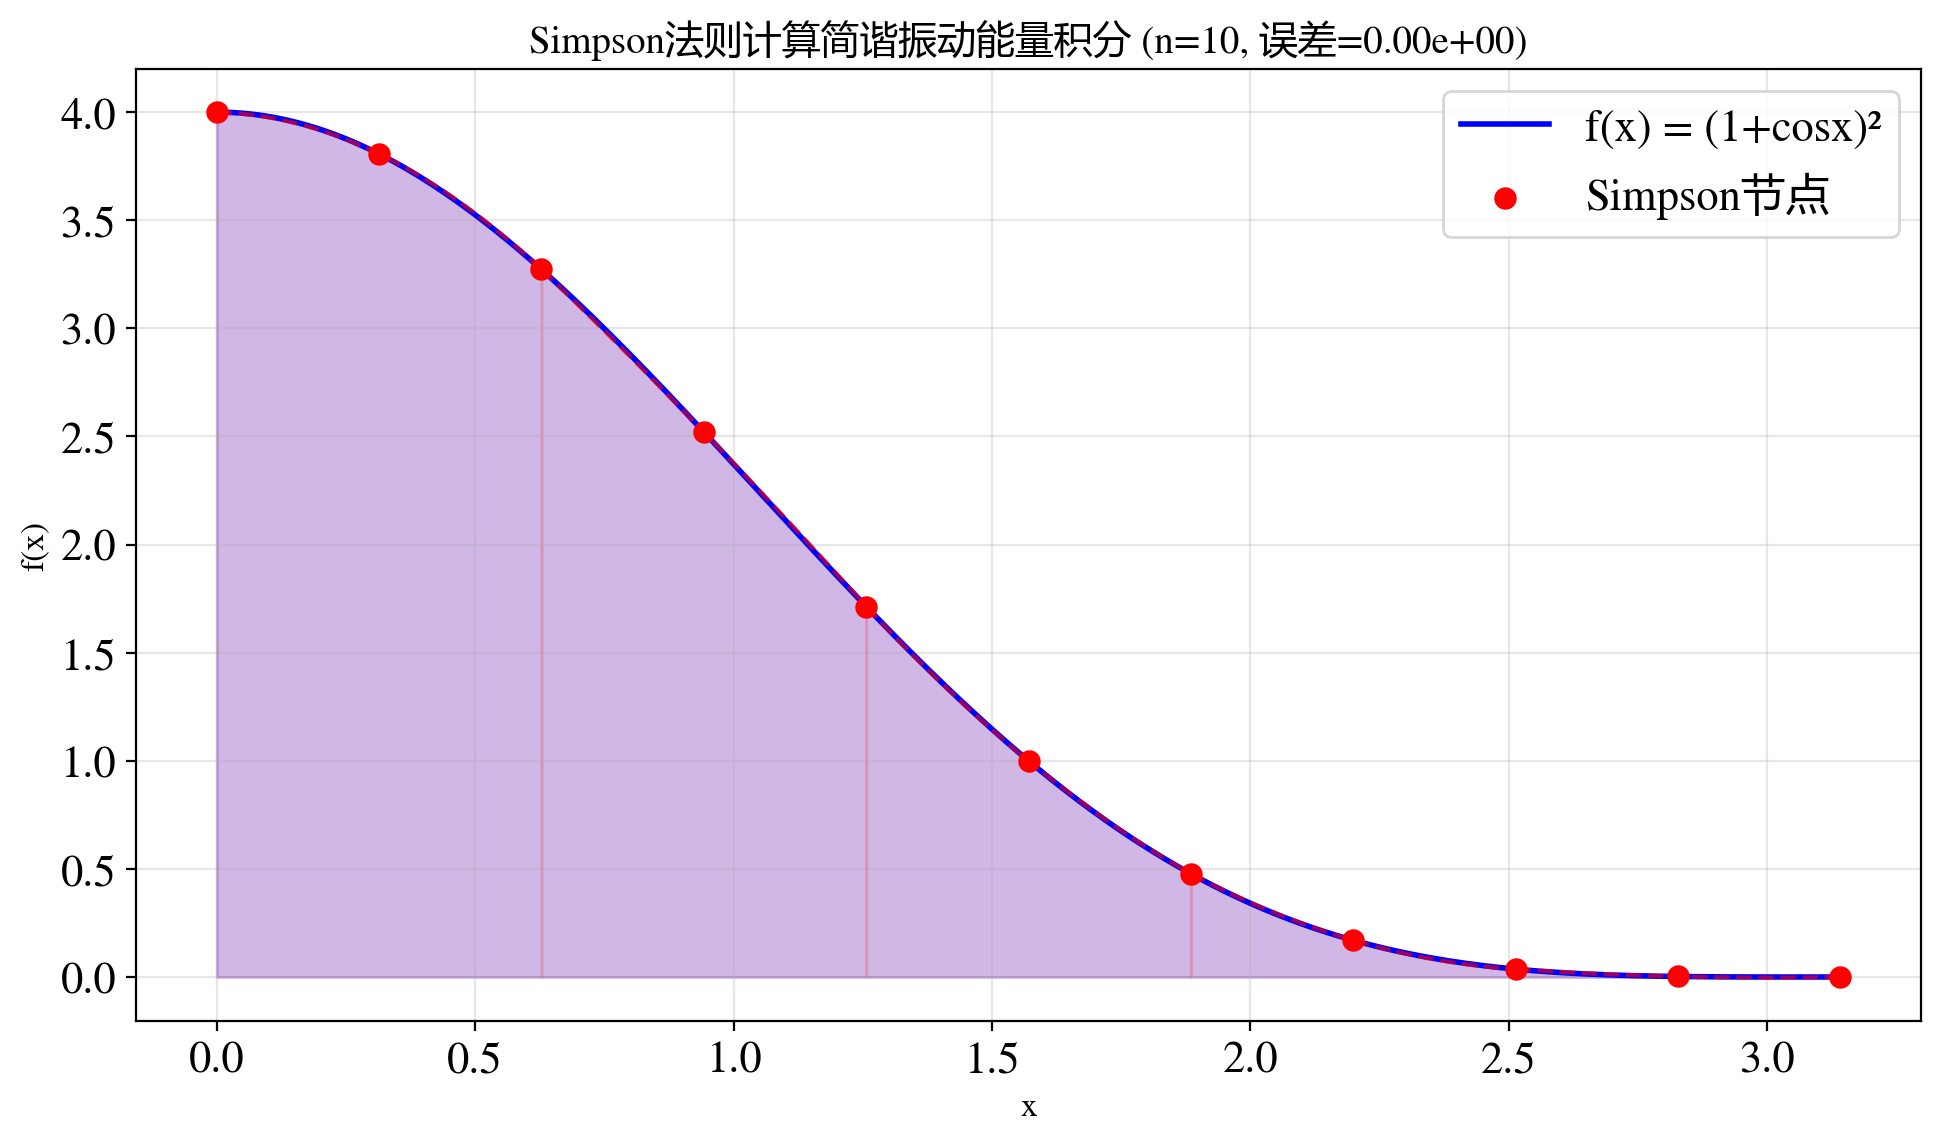

In [96]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import simpson

# 简谐振动能量积分函数
def harmonic_energy(x):
    return (1 + np.cos(x))**2

def simpson_integration(f, a, b, n):
    """
    使用Simpson法则计算积分
    
    参数:
    f: 函数
    a, b: 积分上下限
    n: 子区间数（必须为偶数）
    
    返回:
    积分近似值
    """
    # 确保n是偶数（Simpson法则要求）
    if n % 2 != 0:
        n += 1
        print(f"注意：n必须为偶数，已调整为{n}")
    
    # 生成节点
    x_nodes = np.linspace(a, b, n + 1)
    y_nodes = f(x_nodes)
    
    # 计算Simpson积分
    h = (b - a) / n
    integral = h/3 * (y_nodes[0] + y_nodes[-1] + 
                      4 * np.sum(y_nodes[1:-1:2]) + 
                      2 * np.sum(y_nodes[2:-2:2]))
    
    return integral, x_nodes, y_nodes

# 解析解
def exact_integral():
    """计算精确积分值"""
    # ∫(1+cosx)² dx = ∫(1 + 2cosx + cos²x) dx
    # = ∫(1 + 2cosx + (1+cos2x)/2) dx
    # = ∫(3/2 + 2cosx + 1/2 cos2x) dx
    # = [3x/2 + 2sinx + 1/4 sin2x] from 0 to π
    return 3 * np.pi / 2

# 主要计算
if __name__ == "__main__":
    a, b = 0, np.pi
    
    # 精确解
    exact_value = exact_integral()
    print(f"精确解: {exact_value:.10f}")
    
    # 通过增加n来达到误差<1e-6
    target_error = 1e-6
    n = 10  # 初始n
    
    while True:
        approx_value, x_nodes, y_nodes = simpson_integration(harmonic_energy, a, b, n)
        error = abs(approx_value - exact_value)
        
        print(f"n={n}: 近似值={approx_value:.10f}, 误差={error:.2e}")
        
        if error < target_error:
            print(f"\n达到目标精度! n={n}时误差为{error:.2e} < {target_error:.0e}")
            break
        
        n *= 2  # 加倍节点数
    
    # 可视化
    x_fine = np.linspace(a, b, 400)
    y_fine = harmonic_energy(x_fine)
    
    plt.figure(figsize=(10, 6))
    plt.plot(x_fine, y_fine, 'b-', label='f(x) = (1+cosx)²', linewidth=2)
    plt.fill_between(x_fine, y_fine, alpha=0.2, color='blue')
    
    # 标记节点
    plt.scatter(x_nodes, harmonic_energy(x_nodes), color='red', s=50, zorder=5, label='Simpson节点')
    
    # 绘制二次插值曲线
    for i in range(0, len(x_nodes)-2, 2):
        xs = x_nodes[i:i+3]
        ys = harmonic_energy(xs)
        xx = np.linspace(xs[0], xs[2], 100)
        coeff = np.polyfit(xs, ys, 2)
        yy = np.polyval(coeff, xx)
        plt.plot(xx, yy, 'r--', alpha=0.6)
        plt.fill_between(xx, yy, alpha=0.1, color='red')
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.title(f"Simpson法则计算简谐振动能量积分 (n={n}, 误差={error:.2e})", fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.tight_layout()
    plt.show()



#### 课后题 2：概率密度积分（quad）
计算标准正态分布的概率：
$$
P = \int_{-2}^{2} \frac{1}{\sqrt{2\pi}}e^{-x^2/2}\, dx.
$$

要求：
- 使用 `quad`
- 比较与数值表值 $ \approx 0.9545 $

---



课后题2: 计算标准正态分布概率 P = ∫₋₂² (1/√(2π)) e^{-x²/2} dx
已知数值表值: P ≈ 0.9545

scipy.integrate.quad 结果:
  积分值: 0.9544997361
  误差估计: 1.8403560456e-11
  与数值表值差异: 2.6389635832e-07
  相对差异: 2.7647601710e-07

精确值 (使用误差函数):
  erf(2/√2) = 0.9544997361
  quad结果与精确值差异: 1.1102230246e-16


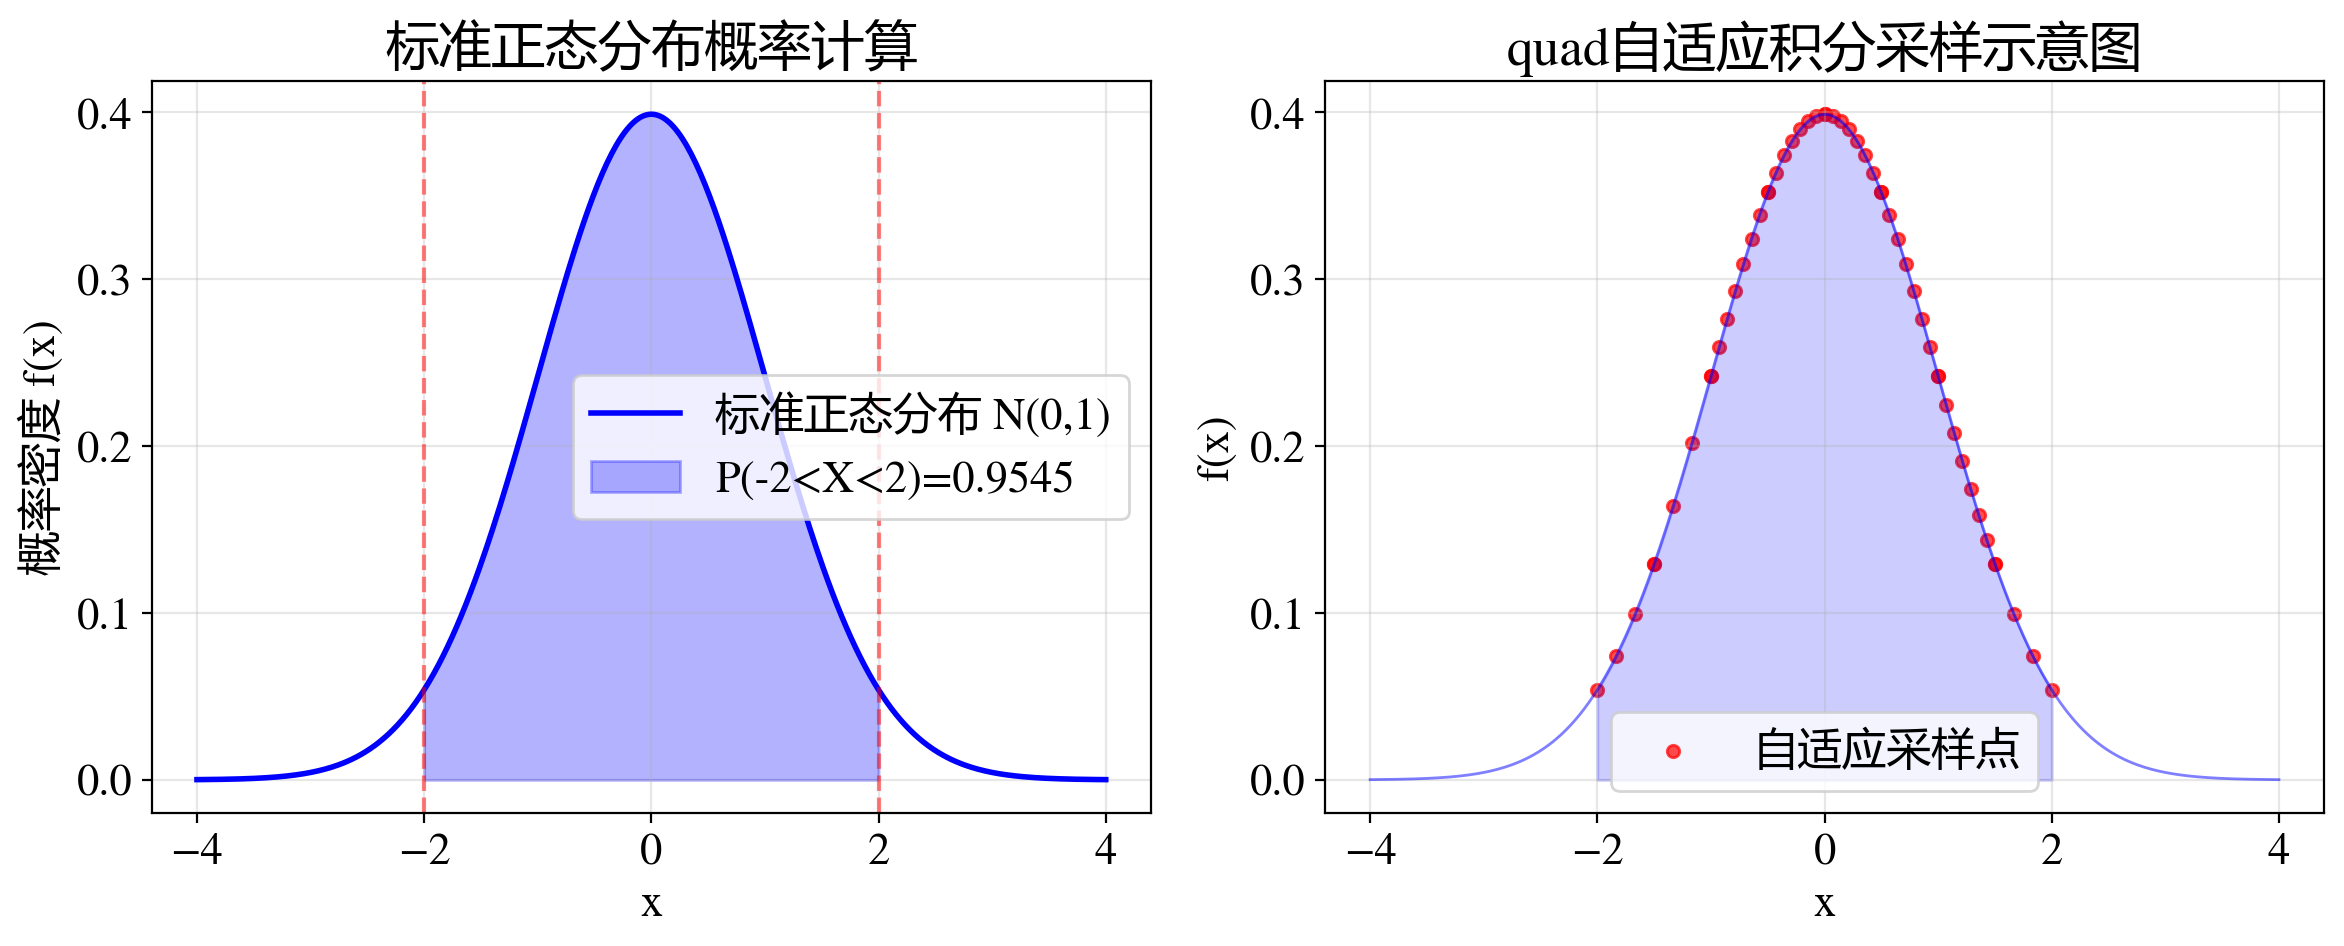


概率解释:
----------------------------------------
1. 标准正态分布 N(0,1) 的概率密度函数: f(x) = (1/√(2π)) e^{-x²/2}
2. P(-2 < X < 2) 表示随机变量X落在±2个标准差内的概率
3. 计算结果: P = 0.954500
4. 这意味着约 95.45% 的数据落在均值±2个标准差内
5. 与数值表值0.9545非常接近，验证了计算的正确性

quad算法说明:
----------------------------------------
1. quad使用自适应高斯-克朗罗德积分法
2. 自动调整子区间划分，在函数变化快的区域增加采样点
3. 默认精度: 绝对误差epsabs=1.49e-8, 相对误差epsrel=1.49e-8
4. 返回积分值和误差估计
5. 对于平滑函数如正态分布，quad通常能快速达到高精度


In [92]:
import numpy as np
from scipy.integrate import quad

# 定义标准正态分布概率密度函数
def fn8(x):
    return (1/np.sqrt(2*np.pi)) * np.exp(-x**2 / 2)

print("课后题2: 计算标准正态分布概率 P = ∫₋₂² (1/√(2π)) e^{-x²/2} dx")
print("="*60)

# 已知数值表值
P_table = 0.9545
print(f"已知数值表值: P ≈ {P_table}")

# 使用quad计算
P_quad, quad_err = quad(fn8, -2, 2)

print(f"\nscipy.integrate.quad 结果:")
print(f"  积分值: {P_quad:.10f}")
print(f"  误差估计: {quad_err:.10e}")
print(f"  与数值表值差异: {abs(P_quad - P_table):.10e}")
print(f"  相对差异: {abs(P_quad - P_table)/P_table:.10e}")

# 计算更精确的理论值（使用误差函数erf）
from scipy.special import erf
P_exact = erf(2/np.sqrt(2))  # P(-2 < X < 2) = erf(2/√2)

print(f"\n精确值 (使用误差函数):")
print(f"  erf(2/√2) = {P_exact:.10f}")
print(f"  quad结果与精确值差异: {abs(P_quad - P_exact):.10e}")

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 左图：标准正态分布曲线
plt.subplot(1, 2, 1)
x_fine = np.linspace(-4, 4, 400)
y_fine = fn8(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='标准正态分布 N(0,1)')

# 填充积分区域 [-2, 2]
x_fill = np.linspace(-2, 2, 200)
y_fill = fn8(x_fill)
plt.fill_between(x_fill, y_fill, alpha=0.3, color='blue', label=f'P(-2<X<2)={P_quad:.4f}')

plt.axvline(x=-2, color='red', linestyle='--', alpha=0.5)
plt.axvline(x=2, color='red', linestyle='--', alpha=0.5)
plt.xlabel('x')
plt.ylabel('概率密度 f(x)')
plt.title('标准正态分布概率计算')
plt.grid(True, alpha=0.3)
plt.legend()

# 右图：quad自适应积分过程示意图
plt.subplot(1, 2, 2)
# 绘制函数曲线
plt.plot(x_fine, y_fine, 'b-', linewidth=1, alpha=0.5)

# 模拟quad的自适应采样（简化版）
# quad会在函数变化快的区域增加采样点
x_samples = []
for seg in [(-2, -1.5), (-1.5, -1), (-1, -0.5), (-0.5, 0), 
            (0, 0.5), (0.5, 1), (1, 1.5), (1.5, 2)]:
    # 在中间区域采样更密集
    a, b = seg
    if abs(a) < 1.5:  # 在中心区域采样更密
        n = 8
    else:
        n = 4
    x_seg = np.linspace(a, b, n)
    x_samples.extend(x_seg)
    
x_samples = np.array(x_samples)
y_samples = fn8(x_samples)

plt.scatter(x_samples, y_samples, color='red', s=20, alpha=0.7, 
           label='自适应采样点')
plt.fill_between(x_fill, y_fill, alpha=0.2, color='blue')

plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('quad自适应积分采样示意图')
plt.grid(True, alpha=0.3)
plt.legend()

plt.tight_layout()
plt.show()

# 概率解释
print("\n概率解释:")
print("-"*40)
print("1. 标准正态分布 N(0,1) 的概率密度函数: f(x) = (1/√(2π)) e^{-x²/2}")
print("2. P(-2 < X < 2) 表示随机变量X落在±2个标准差内的概率")
print(f"3. 计算结果: P = {P_quad:.6f}")
print(f"4. 这意味着约 {P_quad*100:.2f}% 的数据落在均值±2个标准差内")
print("5. 与数值表值0.9545非常接近，验证了计算的正确性")

# quad算法说明
print("\nquad算法说明:")
print("-"*40)
print("1. quad使用自适应高斯-克朗罗德积分法")
print("2. 自动调整子区间划分，在函数变化快的区域增加采样点")
print("3. 默认精度: 绝对误差epsabs=1.49e-8, 相对误差epsrel=1.49e-8")
print("4. 返回积分值和误差估计")
print("5. 对于平滑函数如正态分布，quad通常能快速达到高精度")



#### 课后题 3：高斯求积（fixed_quad）
使用 `fixed_quad` 计算：
$$
\int_0^{1} x^5 e^{-x} dx
$$

要求：
- 测试 n=3, 5, 8
- 比较误差下降趋势

---



高斯求积法计算 ∫₀¹ x⁵ e^{-x} dx
精确解: 0.071302178110
------------------------------------------------------------
n=3: 近似值=0.071335272091, 误差=3.31e-05
n=5: 近似值=0.071302182820, 误差=4.71e-09
n=8: 近似值=0.071302178110, 误差=4.30e-16

额外测试更高阶数:
----------------------------------------
n=10: 近似值=0.071302178110, 误差=5.27e-16
n=15: 近似值=0.071302178110, 误差=3.89e-16
n=20: 近似值=0.071302178110, 误差=2.64e-16


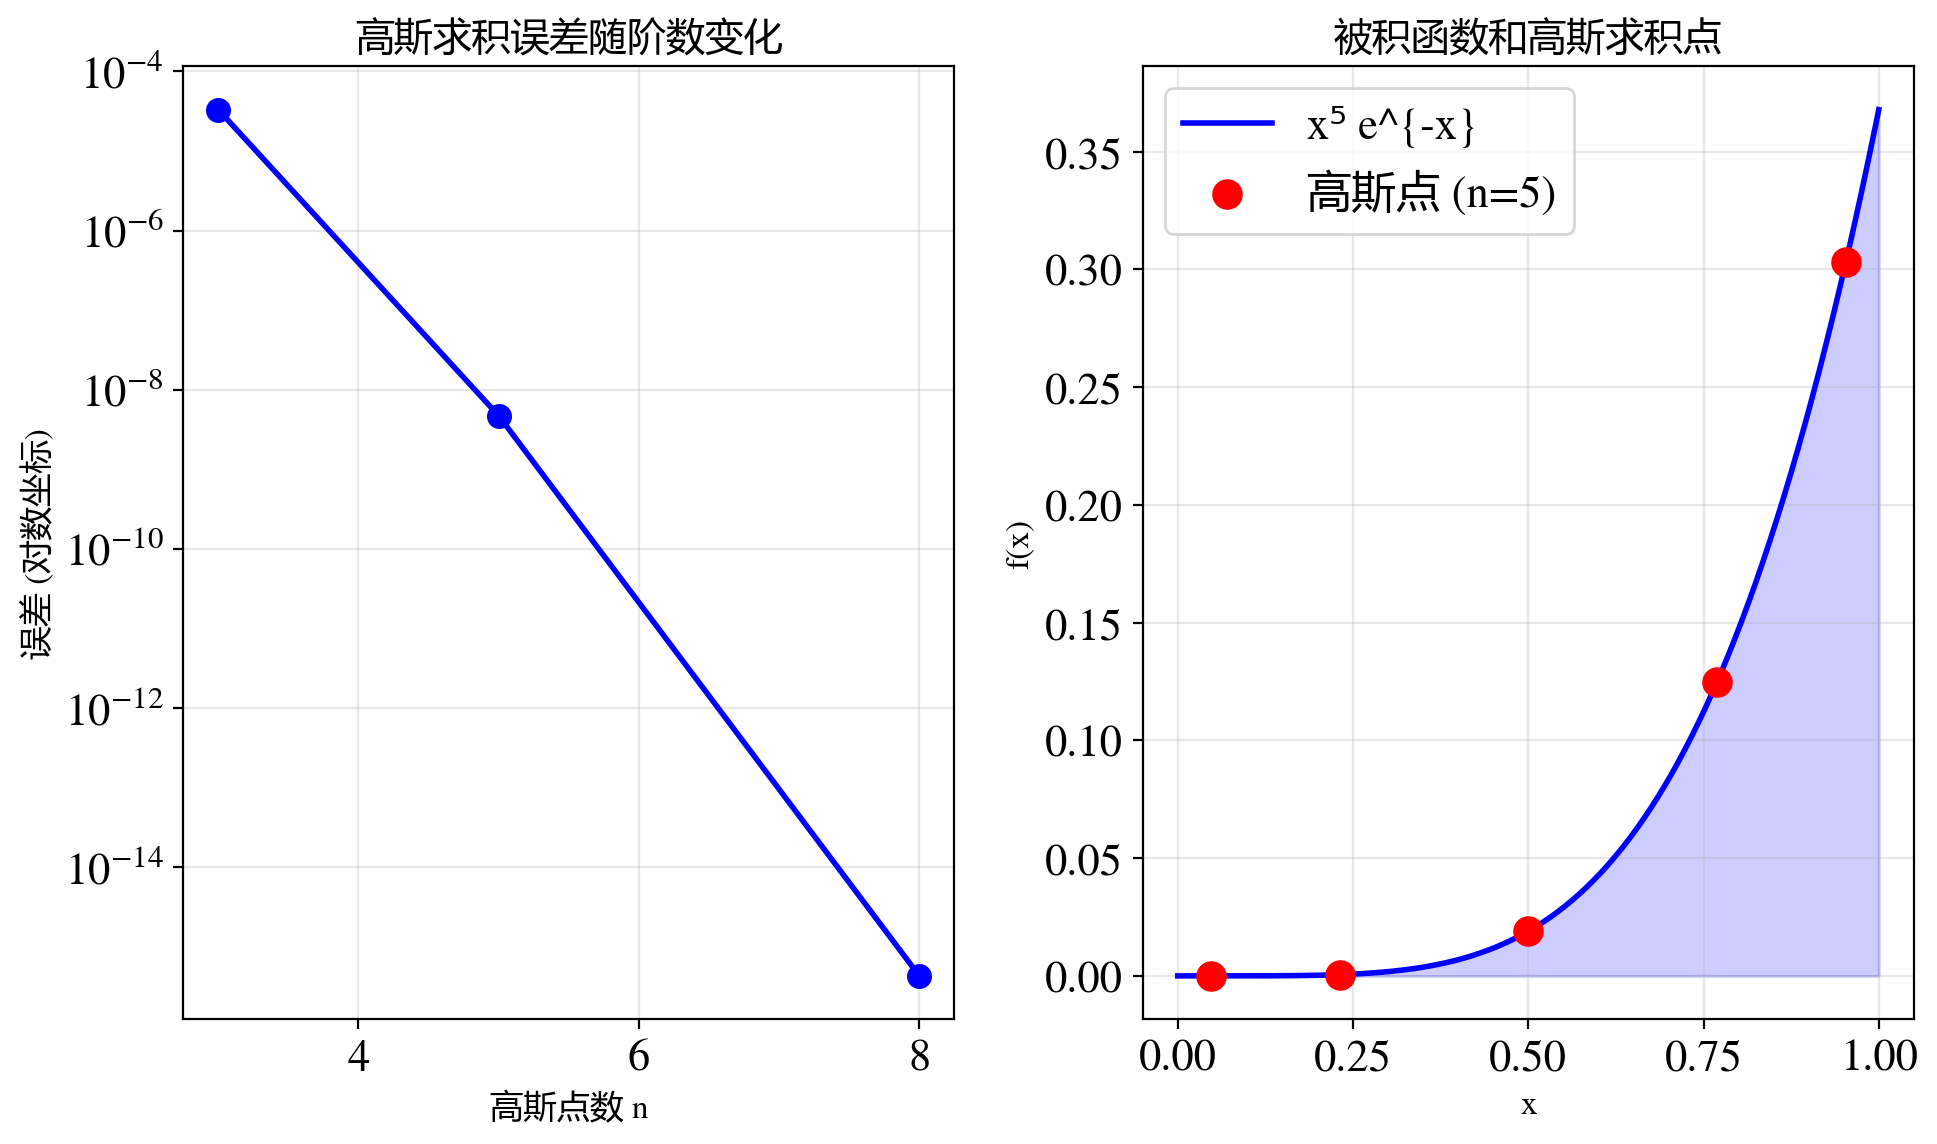


理论分析:
----------------------------------------
高斯求积法的代数精度为2n-1阶。
对于n=3: 代数精度=5，可以精确积分5次多项式
x⁵ e^(-x) 中e^(-x)可以展开为无穷级数，因此需要更高阶
随着n增加，近似精度提高


In [104]:
import numpy as np
from scipy.integrate import fixed_quad
import matplotlib.pyplot as plt

# 被积函数
def integrand(x):
    return x**5 * np.exp(-x)

# 解析解（通过分部积分可得）
def exact_solution():
    """计算精确积分值: ∫₀¹ x⁵ e^{-x} dx"""
    # 使用积分表或符号计算得到精确值
    # 通过分部积分或使用Gamma函数:
    # ∫ x⁵ e^{-x} dx = -e^{-x}(x⁵ + 5x⁴ + 20x³ + 60x² + 120x + 120) + C
    # 在[0,1]上求值:
    # 在1处: -e^{-1}(1 + 5 + 20 + 60 + 120 + 120) = -e^{-1} * 326
    # 在0处: -1 * 120
    # 所以积分值 = 120 - 326/e
    return 120 - 326 / np.e

# 使用fixed_quad计算不同阶数的高斯积分
def compare_gauss_quadrature(n_values):
    """
    比较不同阶数的高斯求积结果
    
    参数:
    n_values: 高斯点数的列表
    
    返回:
    结果字典，包含每个n的近似值和误差
    """
    exact = exact_solution()
    results = {}
    
    print("高斯求积法计算 ∫₀¹ x⁵ e^{-x} dx")
    print("=" * 60)
    print(f"精确解: {exact:.12f}")
    print("-" * 60)
    
    for n in n_values:
        approx, _ = fixed_quad(integrand, 0, 1, n=n)
        error = abs(approx - exact)
        results[n] = {'approx': approx, 'error': error}
        
        print(f"n={n}: 近似值={approx:.12f}, 误差={error:.2e}")
    
    print("=" * 60)
    return results, exact

# 主要计算
if __name__ == "__main__":
    # 测试不同的高斯点数
    n_values = [3, 5, 8]
    
    results, exact_value = compare_gauss_quadrature(n_values)
    
    # 额外测试更高阶数
    print("\n额外测试更高阶数:")
    print("-" * 40)
    for n in [10, 15, 20]:
        approx, _ = fixed_quad(integrand, 0, 1, n=n)
        error = abs(approx - exact_value)
        print(f"n={n:2d}: 近似值={approx:.12f}, 误差={error:.2e}")
    
    # 可视化误差下降趋势
    n_list = list(results.keys())
    errors = [results[n]['error'] for n in n_list]
    
    plt.figure(figsize=(10, 6))
    
    # 误差图
    plt.subplot(1, 2, 1)
    plt.plot(n_list, errors, 'bo-', linewidth=2, markersize=8)
    plt.yscale('log')
    plt.xlabel('高斯点数 n', fontsize=12)
    plt.ylabel('误差 (对数坐标)', fontsize=12)
    plt.title('高斯求积误差随阶数变化', fontsize=14)
    plt.grid(True, alpha=0.3)
    
    # 函数图和高斯点
    plt.subplot(1, 2, 2)
    x = np.linspace(0, 1, 200)
    y = integrand(x)
    plt.plot(x, y, 'b-', linewidth=2, label='x⁵ e^{-x}')
    plt.fill_between(x, y, alpha=0.2, color='blue')
    
    # 绘制n=5时的高斯点
    n = 5
    # 获取Legendre多项式的零点和权重（用于fixed_quad内部）
    from numpy.polynomial.legendre import leggauss
    nodes, _ = leggauss(n)
    # 映射到[0, 1]区间
    nodes_mapped = 0.5 * (nodes + 1)
    plt.scatter(nodes_mapped, integrand(nodes_mapped), color='red', s=100, zorder=5, label=f'高斯点 (n={n})')
    
    plt.xlabel('x', fontsize=12)
    plt.ylabel('f(x)', fontsize=12)
    plt.title('被积函数和高斯求积点', fontsize=14)
    plt.grid(True, alpha=0.3)
    plt.legend()
    
    plt.tight_layout()
    plt.show()
    
    # 理论分析
    print("\n理论分析:")
    print("-" * 40)
    print("高斯求积法的代数精度为2n-1阶。")
    print(f"对于n=3: 代数精度=5，可以精确积分5次多项式")
    print(f"x⁵ e^(-x) 中e^(-x)可以展开为无穷级数，因此需要更高阶")
    print("随着n增加，近似精度提高")


#### 课后题 4：Romberg 精度验证
使用 `romb` 计算：
$$
\int_0^1 \sqrt{x+1}\,dx
$$

并与解析解比较：
$$
\int_0^1 \sqrt{x+1}\,dx = \frac{2}{3}(2\sqrt{2}-1)
$$

课后题4: 使用Romberg积分计算 ∫₀¹ √(x+1) dx
解析解: ∫₀¹ √(x+1) dx = (2/3)(2√2 - 1) = 1.218951416497460

Romberg积分结果 (使用不同k值):
----------------------------------------
k=3, 节点数=9:
  Romberg近似值: 1.218951410028102
  Simpson近似值: 1.218951005387825
  Romberg误差: 6.469358160288152e-09
  Simpson误差: 4.111096347791943e-07
k=4, 节点数=17:
  Romberg近似值: 1.218951416476930
  Simpson近似值: 1.218951390450256
  Romberg误差: 2.053046621597332e-11
  Simpson误差: 2.604720439336461e-08
k=5, 节点数=33:
  Romberg近似值: 1.218951416497434
  Simpson近似值: 1.218951414863789
  Romberg误差: 2.642330798607873e-14
  Simpson误差: 1.633671198320030e-09
k=6, 节点数=65:
  Romberg近似值: 1.218951416497460
  Simpson近似值: 1.218951416395265
  Romberg误差: 2.220446049250313e-16
  Simpson误差: 1.021949191937210e-10
k=7, 节点数=129:
  Romberg近似值: 1.218951416497460
  Simpson近似值: 1.218951416491071
  Romberg误差: 0.000000000000000e+00
  Simpson误差: 6.388889417507926e-12

误差比较:
----------------------------------------
k=3, n=9: Simpson误差/Romberg误差 = 63.55
k=4, n=17: Simpson误差/Romb

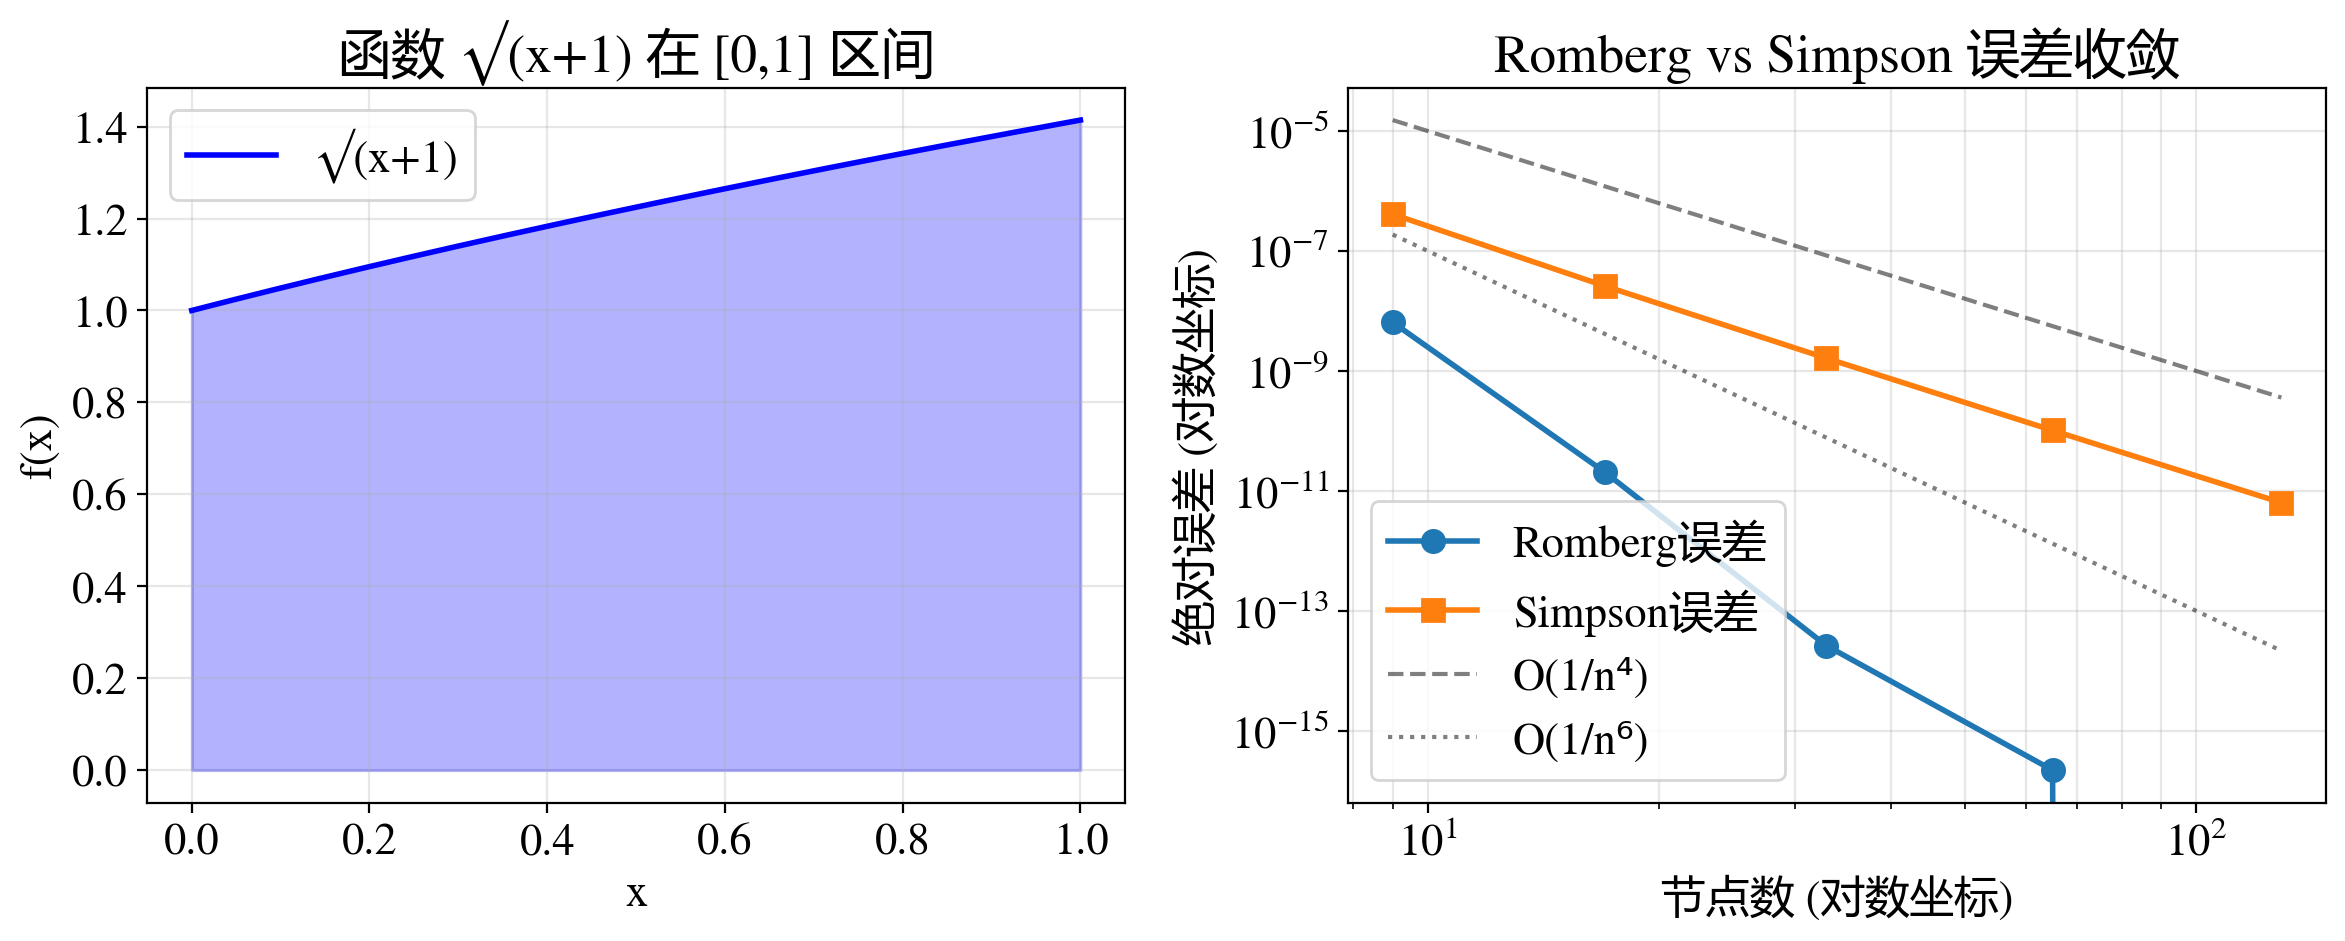


Romberg积分精度分析:
----------------------------------------
1. Romberg积分通过Richardson外推法提高精度
2. 从梯形积分序列出发，构建三角表格
3. 对角线元素R(k,k)收敛最快
4. 节点数要求为2^k+1，保证每次步长减半
5. 理论收敛阶可达到O(1/n^{2k+2})

收敛阶计算:
----------------------------------------
从n=9到n=17:
  Romberg收敛阶: 9.05
  Simpson收敛阶: 4.34
从n=17到n=33:
  Romberg收敛阶: 10.03
  Simpson收敛阶: 4.17
从n=33到n=65:
  Romberg收敛阶: 7.05
  Simpson收敛阶: 4.09
从n=65到n=129:
  Romberg收敛阶: inf
  Simpson收敛阶: 4.04

解析解验证:
----------------------------------------
∫₀¹ √(x+1) dx = ∫₀¹ (x+1)^{1/2} dx
使用幂函数积分公式: ∫ x^n dx = x^{n+1}/(n+1)
令u=x+1, 则du=dx, 当x=0时u=1, x=1时u=2
∫₀¹ √(x+1) dx = ∫₁² u^{1/2} du = [2/3 u^{3/2}]₁²
= (2/3)(2^1.5 - 1) = (2/3)(2√2 - 1) = 1.2189514165


In [94]:
import numpy as np
from scipy.integrate import romb, simpson

# 定义被积函数
def fn10(x):
    return np.sqrt(x + 1)

print("课后题4: 使用Romberg积分计算 ∫₀¹ √(x+1) dx")
print("="*60)

# 解析解
# ∫₀¹ √(x+1) dx = ∫₀¹ (x+1)^{1/2} dx = [2/3 (x+1)^{3/2}]₀¹
# = (2/3)(2^{3/2} - 1^{3/2}) = (2/3)(2√2 - 1)
I_exact = (2/3) * (2*np.sqrt(2) - 1)

print(f"解析解: ∫₀¹ √(x+1) dx = (2/3)(2√2 - 1) = {I_exact:.15f}")
print()

# 使用Romberg积分（使用不同k值）
print("Romberg积分结果 (使用不同k值):")
print("-"*40)

k_values = [3, 4, 5, 6, 7]  # 对应节点数 2^k+1
romb_results = []
romb_errors = []
simp_results = []
simp_errors = []

for k in k_values:
    n = 2**k + 1
    x = np.linspace(0, 1, n)
    y = fn10(x)
    dx = x[1] - x[0]
    
    # Romberg积分
    I_romb = romb(y, dx=dx)
    romb_results.append(I_romb)
    romb_errors.append(abs(I_romb - I_exact))
    
    # Simpson积分
    I_simp = simpson(y, x)
    simp_results.append(I_simp)
    simp_errors.append(abs(I_simp - I_exact))
    
    print(f"k={k}, 节点数={n}:")
    print(f"  Romberg近似值: {I_romb:.15f}")
    print(f"  Simpson近似值: {I_simp:.15f}")
    print(f"  Romberg误差: {romb_errors[-1]:.15e}")
    print(f"  Simpson误差: {simp_errors[-1]:.15e}")

print()

# 误差比较
print("误差比较:")
print("-"*40)
for i, k in enumerate(k_values):
    n = 2**k + 1
    if romb_errors[i] > 0:
        error_ratio = simp_errors[i] / romb_errors[i]
        print(f"k={k}, n={n}: Simpson误差/Romberg误差 = {error_ratio:.2f}")

# 可视化
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 5))

# 左图：函数曲线
plt.subplot(1, 2, 1)
x_fine = np.linspace(0, 1, 400)
y_fine = fn10(x_fine)
plt.plot(x_fine, y_fine, 'b-', linewidth=2, label='√(x+1)')
plt.fill_between(x_fine, y_fine, alpha=0.3, color='blue')
plt.xlabel('x')
plt.ylabel('f(x)')
plt.title('函数 √(x+1) 在 [0,1] 区间')
plt.grid(True, alpha=0.3)
plt.legend()

# 右图：误差收敛比较
plt.subplot(1, 2, 2)
node_counts = [2**k + 1 for k in k_values]

plt.loglog(node_counts, romb_errors, 'o-', linewidth=2, markersize=8, label='Romberg误差')
plt.loglog(node_counts, simp_errors, 's-', linewidth=2, markersize=8, label='Simpson误差')

# 添加理论收敛线
plt.loglog(node_counts, 0.1/np.array(node_counts)**4, 'k--', alpha=0.5, label='O(1/n⁴)')
plt.loglog(node_counts, 0.1/np.array(node_counts)**6, 'k:', alpha=0.5, label='O(1/n⁶)')

plt.xlabel('节点数 (对数坐标)')
plt.ylabel('绝对误差 (对数坐标)')
plt.title('Romberg vs Simpson 误差收敛')
plt.grid(True, alpha=0.3, which='both')
plt.legend()

plt.tight_layout()
plt.show()

# Romberg积分精度分析
print("\nRomberg积分精度分析:")
print("-"*40)
print("1. Romberg积分通过Richardson外推法提高精度")
print("2. 从梯形积分序列出发，构建三角表格")
print("3. 对角线元素R(k,k)收敛最快")
print("4. 节点数要求为2^k+1，保证每次步长减半")
print("5. 理论收敛阶可达到O(1/n^{2k+2})")

# 收敛阶计算
print("\n收敛阶计算:")
print("-"*40)
for i in range(1, len(k_values)):
    n1, n2 = node_counts[i-1], node_counts[i]
    err_romb1, err_romb2 = romb_errors[i-1], romb_errors[i]
    err_simp1, err_simp2 = simp_errors[i-1], simp_errors[i]
    
    if err_romb1 > 0 and err_romb2 > 0:
        order_romb = np.log(err_romb1/err_romb2) / np.log(n2/n1)
    else:
        order_romb = float('inf')
    
    if err_simp1 > 0 and err_simp2 > 0:
        order_simp = np.log(err_simp1/err_simp2) / np.log(n2/n1)
    else:
        order_simp = float('inf')
    
    print(f"从n={n1}到n={n2}:")
    print(f"  Romberg收敛阶: {order_romb:.2f}")
    print(f"  Simpson收敛阶: {order_simp:.2f}")

# 解析解验证
print("\n解析解验证:")
print("-"*40)
print("∫₀¹ √(x+1) dx = ∫₀¹ (x+1)^{1/2} dx")
print("使用幂函数积分公式: ∫ x^n dx = x^{n+1}/(n+1)")
print("令u=x+1, 则du=dx, 当x=0时u=1, x=1时u=2")
print("∫₀¹ √(x+1) dx = ∫₁² u^{1/2} du = [2/3 u^{3/2}]₁²")
print(f"= (2/3)(2^{3/2} - 1) = (2/3)(2√2 - 1) = {I_exact:.10f}")